In [1]:
SEED = 20260916

## Importing the libraries

We implement the *minimal surface problem* using discretizations, which are provided by scikit-fem

In [2]:
%pip install scikit-fem

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.5/178.5 kB 3.2 MB/s eta 0:00:00


We import the standard libaries for numeric and scientifc calculations, as well as plotting.

In [3]:
import sys

# Calculations
import numpy as np
import scipy as sp
from scipy.sparse import csr_matrix, tril, triu
from scipy.sparse.linalg import (LinearOperator, cg, factorized, spsolve, spsolve_triangular)
from skfem import Basis, ElementTriP1, MeshTri, asm
from skfem.models.poisson import laplace

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import (AutoMinorLocator, LogLocator, NullFormatter)

# Performance
from time import perf_counter

## Defining the functions

As an easier toy problem, we can create "random"$^1$ spd matrices of a given condition number.

$^1$ We make no particular claims about the probability distribution and/or usefulness of the code in a production setting.

In [42]:
# This code snippet was largely inspired by https://gist.github.com/bstellato/23322fe5d87bb71da922fbc41d658079,
# We show a symplified version
def random_spd_with_condition(n, cond_number, rng):
    # Get random orthogonal matrices from the QR decomposition of random matrices
    A = rng.normal(size = (n, n))
    U, _ = sp.linalg.qr(A)

    # Construct the diagonal eigenvalue matrix S such that we have the desired condition number
    log_min = -np.log(cond_number)
    log_max = 0
    eigenvalues = np.exp(np.linspace(log_min, log_max, n))
    S = np.diag(eigenvalues)

    # Actually construct the spd matrix
    M = U @ S @ U.T

    return M

What follows is an implementation of the *minimal surface problem*, which was ported by Claude Fable 5 from MATLAB to Python.

In [5]:
"""Finite-element minimal-surface problem as a quasi-Newton test problem.

* ``problem.input_dimension``            -- number of unknowns (interior DOFs)
* ``problem.name``                       -- human-readable identifier
* ``problem.num_f_evals``                -- objective evaluation counter
* ``problem.num_grad_evals``             -- gradient evaluation counter
* ``problem.reset()``                    -- reset both counters
* ``problem.objective(x)``               -- discrete surface area (counts)
* ``problem.derivative(x)``              -- analytic gradient (counts)
* ``problem.x0``                         -- default initial guess
* ``problem.global_min``                 -- ``None`` until
  ``problem.compute_global_min()`` has produced a high-accuracy reference
  solution with a preconditioned Newton-CG method (there is no closed form).

In addition the module provides

* ``problem.poisson_solve(r)``           -- exact ``A^{-1} r`` where ``A`` is
  the Poisson (Laplace) stiffness matrix on the interior nodes of the finest
  mesh, realised by a cached sparse LU factorisation;
* ``problem.precondition(r)``            -- one geometric multigrid V/W-cycle
  approximating the same ``A^{-1} r`` (the MATLAB ``pc`` handle);

Problem sizes (uniform red refinement of the 4-triangle mesh of
``[-1, 1]^2``): with ``L = n`` levels the number of interior unknowns is

    n_int(L) = 4**L // 2 - 2**L + 1

      L :   1   2    3     4     5      6      7       8        9
  n_int :   1   5   25   113   481   1985   8065   32513   130561

A dense n-by-n inverse BFGS matrix is comfortable up to L = 6 (~32 MB) and
possible at L = 7 (~0.5 GB);
"""
# ---------------------------------------------------------------------------
# Finite-element hierarchy
# ---------------------------------------------------------------------------

class LevelData:
    """Data belonging to one level of the nested finite-element hierarchy."""

    def __init__(self, mesh, basis, boundary, interior, boundary_values,
                 stiffness, prolongation, lower, strict_upper, strict_lower,
                 upper):
        self.mesh = mesh
        self.basis = basis
        self.boundary = boundary
        self.interior = interior
        self.boundary_values = boundary_values
        self.stiffness = stiffness
        self.prolongation = prolongation
        self.lower = lower
        self.strict_upper = strict_upper
        self.strict_lower = strict_lower
        self.upper = upper


def interior_dimension(n_levels):
    """Number of interior P1 unknowns after ``n_levels`` levels."""
    return 4 ** n_levels // 2 - 2 ** n_levels + 1


# ---------------------------------------------------------------------------
# The optimisation problem
# ---------------------------------------------------------------------------

class MinimalSurfaceProblem:
    """Discrete minimal-surface problem with a ``QuadraticProblem``-like API.

    The unknowns are the values of a piecewise-linear function at the
    interior nodes of the finest mesh; Dirichlet values are eliminated.
    ``objective`` is the exact area of the graph, ``derivative`` its
    analytic gradient.
    """

    def __init__(self, levels, boundary_function, Gx, Gy, Bx, By, areas, x0,
                 gamma=1, m_pre=1, m_post=1):
        self.levels = levels
        self.boundary_function = boundary_function
        self.Gx = Gx
        self.Gy = Gy
        self.Bx = Bx
        self.By = By
        self.areas = areas
        self.x0 = x0
        self.gamma = gamma
        self.m_pre = m_pre
        self.m_post = m_post

        self.input_dimension = self.finest.interior.size
        self.name = (f"Minimal surface (levels = {len(levels)}, "
                     f"n = {self.input_dimension})")
        self.num_f_evals = 0
        self.num_grad_evals = 0
        self._poisson_factor = None

    def reset(self):
        self.num_f_evals = 0
        self.num_grad_evals = 0

    def objective(self, x):
        self.num_f_evals += 1
        return self.energy(x)

    def derivative(self, x):
        self.num_grad_evals += 1
        _, gradient = self.energy(x, gradient=True)
        return gradient

    @property
    def finest(self):
        return self.levels[-1]

    @property
    def n_interior(self):
        return self.finest.interior.size

    def expand(self, x):
        """Insert the fixed Dirichlet values into an interior unknown vector."""
        x_arr = np.asarray(x, dtype=float).reshape(-1)
        if x_arr.size != self.n_interior:
            raise ValueError(f"Expected {self.n_interior} interior values, "
                             f"got {x_arr.size}.")
        full = np.zeros(self.finest.basis.N, dtype=float)
        full[self.finest.interior] = x_arr
        full[self.finest.boundary] = self.finest.boundary_values
        return full

    def energy(self, x, gradient=False, hessian=False):
        """Evaluate the area functional and optionally its derivatives.

        ``energy(x)`` returns ``f``; ``energy(x, gradient=True)`` returns
        ``(f, g)``; ``energy(x, hessian=True)`` returns ``(f, g, H)`` with
        ``H(v)`` a matrix-free Hessian-vector product.  Counters are *not*
        incremented here; use ``objective`` / ``derivative`` for that.
        """
        x_arr = np.asarray(x, dtype=float).reshape(-1)
        full = self.expand(x_arr)
        ux = np.asarray(self.Gx @ full).reshape(-1)
        uy = np.asarray(self.Gy @ full).reshape(-1)
        s = np.sqrt(1.0 + ux * ux + uy * uy)
        value = float(self.areas @ s)
        if not gradient and not hessian:
            return value
        weight = self.areas / s
        grad_value = np.asarray(self.Bx.T @ (weight * ux)
                                + self.By.T @ (weight * uy)).reshape(-1)
        if not hessian:
            return value, grad_value
        weight3 = self.areas / (s * s * s)

        def apply_hessian(v):
            v_arr = np.asarray(v, dtype=float).reshape(-1)
            vx = np.asarray(self.Bx @ v_arr).reshape(-1)
            vy = np.asarray(self.By @ v_arr).reshape(-1)
            directional = ux * vx + uy * vy
            flux_x = weight * vx - weight3 * ux * directional
            flux_y = weight * vy - weight3 * uy * directional
            return np.asarray(self.Bx.T @ flux_x
                              + self.By.T @ flux_y).reshape(-1)

        return value, grad_value, apply_hessian

    def hessp(self, x, v):
        """Hessian-vector product at ``x`` (no counting)."""
        _, _, hess = self.energy(x, hessian=True)
        return hess(v)

    # --- preconditioners ---------------------------------------------------

    def poisson_solve(self, rhs):
        """Exact ``A^{-1} rhs`` for the interior Laplace stiffness matrix.

        The sparse LU factorisation is computed once on first use and
        cached, so each application costs only two triangular solves.
        """
        if self._poisson_factor is None:
            self._poisson_factor = factorized(
                self.finest.stiffness.tocsc())
        b = np.asarray(rhs, dtype=float).reshape(-1)
        return np.asarray(self._poisson_factor(b), dtype=float).reshape(-1)

    def precondition(self, rhs):
        """Apply one geometric multigrid cycle to the Laplace operator.

        With ``m_pre == m_post`` (forward Gauss-Seidel pre-, backward
        Gauss-Seidel post-smoothing) the cycle is a symmetric positive
        definite approximation of ``A^{-1}``
        """
        b = np.asarray(rhs, dtype=float).reshape(-1)
        if b.size != self.n_interior:
            raise ValueError(f"Expected a vector of length "
                             f"{self.n_interior}, got {b.size}.")
        return self._multigrid(len(self.levels) - 1, np.zeros_like(b), b)

    def preconditioner(self, kind="poisson"):
        """Return ``M^{-1}`` as a callable: 'poisson', 'multigrid' or 'identity'."""
        if kind == "poisson":
            return self.poisson_solve
        if kind == "multigrid":
            return self.precondition
        if kind == "identity":
            return lambda r: np.asarray(r, dtype=float).reshape(-1)
        raise ValueError(f"Unknown preconditioner kind '{kind}'.")

    def preconditioner_operator(self, kind="poisson"):
        """Return ``M^{-1}`` as a SciPy ``LinearOperator``."""
        n = self.n_interior
        return LinearOperator((n, n), matvec=self.preconditioner(kind),
                              dtype=float)

    def _multigrid(self, level_index, x, b):
        level = self.levels[level_index]
        A = level.stiffness
        if level_index == 0:
            return np.asarray(spsolve(A, b), dtype=float).reshape(-1)
        for _ in range(self.gamma):
            x = _gauss_seidel(level, x, b, self.m_pre, forward=True)
            residual = b - A @ x
            coarse_rhs = np.asarray(level.prolongation.T
                                    @ residual).reshape(-1)
            coarse_error = self._multigrid(level_index - 1,
                                           np.zeros_like(coarse_rhs),
                                           coarse_rhs)
            x = x + level.prolongation @ coarse_error
            x = _gauss_seidel(level, x, b, self.m_post, forward=False)
        return np.asarray(x, dtype=float).reshape(-1)

    # --- plotting ----------------------------------------------------------

    def plot(self, x, ax=None, show=True, title = None):
        """Plot the graph of the finite-element function as a surface."""
        full = self.expand(x)
        mesh = self.finest.mesh
        triangulation = Triangulation(mesh.p[0], mesh.p[1], mesh.t.T)
        if ax is None:
            figure = plt.figure(figsize = (8, 8), layout = "constrained")
            ax = figure.add_subplot(111, projection="3d")
            ax.set_box_aspect(None, zoom=0.92)
        ax.plot_trisurf(triangulation, full, linewidth=0.2, antialiased=True)
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_zlabel("$q_T$")

        if title == None:
          ax.set_title(self.name, multialignment = "center")
        else:
          ax.set_title(title, multialignment = "center")

        if show:
            plt.show()
        return ax

In [6]:
# ---------------------------------------------------------------------------
# Problem setup
# ---------------------------------------------------------------------------

def setup_minimal_surface(n, boundary=None, initial_mesh=None, gamma=1,
                          m_pre=1, m_post=1):
    """Create objective handle, preconditioner and problem structure.

    Parameters
    ----------
    n:
        Number of mesh levels; level 1 is the coarse mesh, each further
        level one uniform refinement.  ``interior_dimension(n)`` unknowns.
    boundary:
        ``boundary(x, y)`` returning Dirichlet values.  Default is the
        ``0.5 - abs(y))``.
    initial_mesh:
        Coarsest scikit-fem mesh; default is ``[-1, 1]^2`` split into four
        triangles around the origin (the role of MATLAB's ``squareg``).
    gamma, m_pre, m_post:
        Multigrid cycle type (1 = V, 2 = W) and smoothing step counts.

    Returns
    -------
    problem:
        :class:`MinimalSurfaceProblem`
    """
    if n < 1:
        raise ValueError("n must be at least 1.")
    if gamma < 1 or m_pre < 0 or m_post < 0:
        raise ValueError("Require gamma >= 1 and nonnegative smoothing "
                         "counts.")
    if boundary is None:
        boundary = lambda x, y: 0.5 * (1.0 - 2.0 * np.abs(y))
    if initial_mesh is None:
        initial_mesh = _centered_square_mesh()

    levels = []
    mesh = initial_mesh
    for level_number in range(n):
        if level_number > 0:
            mesh = mesh.refined()
        basis = Basis(mesh, ElementTriP1())
        boundary_dofs = np.asarray(basis.get_dofs().flatten(),
                                   dtype=np.int64)
        all_dofs = np.arange(basis.N, dtype=np.int64)
        interior_dofs = np.setdiff1d(all_dofs, boundary_dofs,
                                     assume_unique=True)
        if interior_dofs.size == 0:
            raise ValueError("The coarsest mesh must contain at least one "
                             "interior P1 DOF.")
        boundary_values = _evaluate_boundary(
            boundary, basis.doflocs[:, boundary_dofs])
        stiffness_full = asm(laplace, basis).tocsr()
        stiffness = stiffness_full[interior_dofs][:, interior_dofs].tocsr()
        prolongation = None
        if levels:
            coarse = levels[-1]
            prolongation_full = _p1_uniform_prolongation(coarse.mesh, mesh)
            prolongation = prolongation_full[interior_dofs][:,
                                                            coarse.interior].tocsr()
        level = LevelData(mesh=mesh, basis=basis, boundary=boundary_dofs,
                          interior=interior_dofs,
                          boundary_values=boundary_values,
                          stiffness=stiffness, prolongation=prolongation,
                          lower=tril(stiffness, format="csr"),
                          strict_upper=triu(stiffness, k=1, format="csr"),
                          strict_lower=tril(stiffness, k=-1, format="csr"),
                          upper=triu(stiffness, format="csr"))
        levels.append(level)

    finest = levels[-1]
    Gx, Gy, areas = _element_gradient_matrices(finest.mesh, finest.basis.N)
    Bx = Gx[:, finest.interior].tocsr()
    By = Gy[:, finest.interior].tocsr()
    x, y = finest.basis.doflocs[:, finest.interior]
    x0 = 0.5 - np.abs(y)
    problem = MinimalSurfaceProblem(levels=levels,
                                    boundary_function=boundary,
                                    Gx=Gx, Gy=Gy, Bx=Bx, By=By, areas=areas,
                                    x0=np.asarray(x0, dtype=float),
                                    gamma=gamma, m_pre=m_pre, m_post=m_post)
    return problem

def randomize_initial_guess(problem, rng, amplitude=0.2, modes=3):
    x, y = problem.finest.basis.doflocs[:, problem.finest.interior]
    z = np.zeros_like(x)
    for _ in range(modes):
        kx, ky = rng.integers(1, 5, size=2)
        a = rng.uniform(-1.0, 1.0)
        z += a * np.sin(0.5 * np.pi * kx * (x + 1)) \
               * np.sin(0.5 * np.pi * ky * (y + 1))
    return amplitude * z


def scherk_boundary(c=1.0):
    """Boundary data of Scherk's minimal surface (requires ``c < pi/2``).

    The continuous solution is ``(log(cos(c x)) - log(cos(c y))) / c``,
    which is useful to validate computed discrete solutions.
    """
    if not 0.0 < c < 0.5 * np.pi:
        raise ValueError("Scherk data requires 0 < c < pi/2.")
    return lambda x, y: (np.log(np.cos(c * np.asarray(x)))
                         - np.log(np.cos(c * np.asarray(y)))) / c


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def check_derivatives(problem, x=None, seed=SEED, epsilon=1e-6):
    """Centered finite-difference checks for gradient and Hessian action."""
    rng = np.random.default_rng(seed)
    x_arr = np.array(problem.x0 if x is None else x, dtype=float, copy=True)
    direction = rng.standard_normal(problem.n_interior)
    direction /= np.linalg.norm(direction)
    _, gradient = problem.energy(x_arr, gradient=True)
    fd = (problem.energy(x_arr + epsilon * direction)
          - problem.energy(x_arr - epsilon * direction)) / (2.0 * epsilon)
    exact = float(gradient @ direction)
    hess_action = problem.hessp(x_arr, direction)
    grad_plus = problem.energy(x_arr + epsilon * direction, gradient=True)[1]
    grad_minus = problem.energy(x_arr - epsilon * direction, gradient=True)[1]
    hess_fd = (grad_plus - grad_minus) / (2.0 * epsilon)
    return {
        "gradient_directional_error": abs(fd - exact),
        "hessian_relative_error": float(
            np.linalg.norm(hess_fd - hess_action)
            / max(1.0, np.linalg.norm(hess_action))),
    }


def _p1_uniform_prolongation(coarse_mesh, fine_mesh):
    """P1 nodal interpolation matrix from a mesh to its uniform refinement.

    Exploits nestedness instead of generic point location: every fine
    vertex is either a coarse vertex (weight 1) or the midpoint of exactly
    one coarse edge (weights 1/2, 1/2).  Vertices are matched by quantised
    coordinates, so the routine is independent of the refinement's vertex
    ordering.  Runs in O(#fine vertices) time and memory -- the
    ``basis.probes`` alternative must *search* for the coarse element
    containing each fine point and allocates point-location temporaries of
    up to O(#points x #elements), which exhausts memory around level 8.
    """
    cp = np.asarray(coarse_mesh.p, dtype=float)
    fp = np.asarray(fine_mesh.p, dtype=float)
    t = np.asarray(coarse_mesh.t)
    edges = np.unique(
        np.sort(np.hstack((t[[0, 1]], t[[1, 2]], t[[2, 0]])), axis=0).T,
        axis=0)
    quantum = max(float(np.max(np.abs(cp))), 1.0) * 1e-12

    def keys(points):
        quantised = np.round(points / quantum).astype(np.int64)
        return list(zip(quantised[0].tolist(), quantised[1].tolist()))

    vertex_of = {key: i for i, key in enumerate(keys(cp))}
    midpoints = 0.5 * (cp[:, edges[:, 0]] + cp[:, edges[:, 1]])
    edge_of = {key: j for j, key in enumerate(keys(midpoints))}
    rows, cols, vals = [], [], []
    for i, key in enumerate(keys(fp)):
        if key in vertex_of:
            rows.append(i)
            cols.append(vertex_of[key])
            vals.append(1.0)
        elif key in edge_of:
            a, b = edges[edge_of[key]]
            rows.extend((i, i))
            cols.extend((int(a), int(b)))
            vals.extend((0.5, 0.5))
        else:
            raise ValueError("The fine mesh is not the uniform refinement "
                             "of the coarse mesh.")
    return csr_matrix((vals, (rows, cols)),
                      shape=(fp.shape[1], cp.shape[1]))


def _centered_square_mesh():
    """Coarse P1 mesh of [-1, 1]^2 with one interior vertex."""
    points = np.array([[-1.0, 1.0, 1.0, -1.0, 0.0],
                       [-1.0, -1.0, 1.0, 1.0, 0.0]])
    triangles = np.array([[0, 1, 2, 3],
                          [1, 2, 3, 0],
                          [4, 4, 4, 4]], dtype=np.int64)
    return MeshTri(points, triangles)


def _evaluate_boundary(boundary, points):
    values = np.asarray(boundary(points[0], points[1]), dtype=float)
    if values.ndim == 0:
        values = np.full(points.shape[1], float(values))
    values = values.reshape(-1)
    if values.size != points.shape[1]:
        raise ValueError("The boundary function must return one value per "
                         "boundary point.")
    return values


def _element_gradient_matrices(mesh, n_dofs):
    """Matrices mapping P1 nodal values to elementwise gradients."""
    vertices = mesh.t
    x = mesh.p[0, vertices]
    y = mesh.p[1, vertices]
    determinant = ((x[1] - x[0]) * (y[2] - y[0])
                   - (x[2] - x[0]) * (y[1] - y[0]))
    if np.any(np.isclose(determinant, 0.0)):
        raise ValueError("The mesh contains a degenerate triangle.")
    gradient_x = np.vstack((y[1] - y[2], y[2] - y[0], y[0] - y[1])) \
        / determinant
    gradient_y = np.vstack((x[2] - x[1], x[0] - x[2], x[1] - x[0])) \
        / determinant
    n_elements = vertices.shape[1]
    rows = np.repeat(np.arange(n_elements), 3)
    columns = vertices.T.reshape(-1)
    Gx = csr_matrix((gradient_x.T.reshape(-1), (rows, columns)),
                    shape=(n_elements, n_dofs))
    Gy = csr_matrix((gradient_y.T.reshape(-1), (rows, columns)),
                    shape=(n_elements, n_dofs))
    areas = 0.5 * np.abs(determinant)
    return Gx, Gy, np.asarray(areas, dtype=float)


def _gauss_seidel(level, x, b, steps, forward):
    """Forward or backward Gauss-Seidel smoothing steps."""
    result = np.asarray(x, dtype=float).reshape(-1)
    if forward:
        for _ in range(steps):
            result = spsolve_triangular(level.lower,
                                        b - level.strict_upper @ result,
                                        lower=True)
    else:
        for _ in range(steps):
            result = spsolve_triangular(level.upper,
                                        b - level.strict_lower @ result,
                                        lower=False)
    return np.asarray(result, dtype=float).reshape(-1)

## Defining the stopping criteria

We offer two mesh-independent stopping criterion, both of which stop after a given number of maximally allowed iterations regardless of whether the original stopping criterion was activated.

Since we have direct access to terms like $r_k^T H_{k} r_k = ||r||^2_{H_{k}}$, we expect the squared tolerance.

In [7]:
# Uses the precomputed quasi-Newton decrement r_k^T H_k r_k = -r_k^T d_k = -phi_prime_0,
# which is already computed in every quasi-Newton loop and therefore free.
class DecrementStoppingCriterion:
  def __init__(self, sq_tol = 1e-10, k_max = 500):
    self.sq_tol = sq_tol
    self.k_max = k_max

  def conditions_met(self, f_k, k, decrement, residual):
    return (k > self.k_max) or (decrement <= self.sq_tol)

# the preconditioner norm r_k^T M^{-1} r_k (using apply_m_inverse)
class PreconditionerStoppingCriterion:
  def __init__(self, sq_tol = 1e-10, k_max = 500, apply_m_inverse = None):
    self.sq_tol = sq_tol
    self.k_max = k_max
    self.apply_m_inverse = apply_m_inverse

  def conditions_met(self, f_k, k, decrement, residual):
    preconditiner_norm = residual @ self.apply_m_inverse(residual)
    return (k > self.k_max) or (preconditiner_norm <= self.sq_tol)

## Defining the possible step size functions

Concrete implementations of the Algorithms 5.18 from [Herzog (2023)](https://scoop.iwr.uni-heidelberg.de/teaching/2023ss/lecture-nonlinear-optimization/nonlinear-optimization-lecture-notes-20230718.pdf).

In [8]:
class WolfePowellLineSearch:
  def __init__(self, sigma = 1.0e-2, tau = 0.9, gamma = 1.5, gamma_lower = 0.25, gamma_upper = 0.25, l_max = 200):
    assert 0.0 < sigma < tau < 1.0, "Wolfe-Powell: requires 0.0 < sigma < tau < 1.0."
    assert gamma > 1.0, "Wolfe-Powell: requires gamma > 1.0."
    assert l_max >= 0, "Wolfe-Powell: Maximal number of iterations should be non-negative"
    assert 0.0 <= gamma_lower < 1.0, "Wolfe-Powell: requires 0.0 < gamma_lower < 1.0."
    assert 0.0 <= gamma_upper < 1.0, "Wolfe-Powell: requires 0.0 < gamma_lower < 1.0."
    assert 0.0 <= gamma_lower + gamma_upper < 1.0, "Wolfe-Powell: requires 0.0 < gamma_lower + gamma_upper < 1.0."

    self.sigma = sigma
    self.tau   = tau
    self.gamma = gamma
    self.gamma_lower = gamma_lower
    self.gamma_upper = gamma_upper
    self.l_max = l_max

  def line_search(self, alpha_0, phi, phi_prime, phi_0, phi_prime_0):
    l1 = 0
    l2 = 0

    assert alpha_0 > 0.0, "Wolfe-Powell: requires alpha_0 > 0"

    a = 0
    b = alpha_0

    if phi_prime_0 >= 0:
      return None, None, l1, l2, 2, "Line search - Direction is not a descent direction"

    armijo_bound = lambda alpha: phi_0 + self.sigma * alpha * phi_prime_0

    # Phase 1
    while True:
      l1 += 1
      phi_b = phi(b)

      if phi_b > armijo_bound(b):
        break

      phi_prime_b = phi_prime(b)

      if phi_prime_b >= self.tau * phi_prime_0:
        return b, phi_b, l1, l2, 0, None

      a = b

      b = self.gamma * b

      if l1 >= self.l_max:
        return None, None, l1, l2, 3, "Line search - Maximum number of iterations exceeded in phase 1"

    #Phase 2
    alpha = b
    phi_alpha = phi(alpha)

    while l2 < self.l_max:
      # Calcuates the midpoint of the enclosure interval
      alpha = ((a + self.gamma_lower * (b - a)) + (b - self.gamma_upper * (b - a))) / 2.0
      phi_alpha = phi(alpha)
      l2 += 1

      if phi_alpha > armijo_bound(alpha):
        b = alpha
        continue

      phi_prime_alpha = phi_prime(alpha)

      if phi_prime_alpha < self.tau * phi_prime_0:
        a = alpha
      else:
        return alpha, phi_alpha, l1, l2, 0, None

    return None, None, l1, l2, 4, "Line search - Maximum number of iterations exceeded in phase 2"

## Quasi-Newton update formulas

Here we implement the algorithms from Chapter 3 of our Master thesis, as well as Limited Memory variants for some of them.

The Class structure is highly specialized to our testing environment and may look different in a production setting. For example, reset() is designed in order to be able to use a quasi-Newton instance for problems of different dimensions without having to initialize a new instance.

The central function **calculate**, however, is written in a generally applicable way. For the Limited Memory variants, one could further optimize the **update** function, for example, by being able to switch between different methods of updating, as discussed in Section 3.5.

### Inverse BFGS

In [9]:
# Matrix-valued original inverse BFGS

class InverseBFGS:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n

    self.apply_B0 = apply_B0
    # In general, the initial matrix may only be accessible by matrix-vector product.
    # So, here we have to materialize it by observing its action on the Euclidean basis
    #
    # This is obviously only sensible since we want to compare the matrix and matrix-free
    # algorithms. In a production environment, this may not be useful
    I = np.eye(n)
    self.B = np.column_stack([apply_B0(I[:, j]) for j in range(n)])
    self.B = (self.B + self.B.T)  / 2 # ensures that B really is symmetric

    self.k = 0

  def calculate(self, d):
    return self.B @ d.copy()

  def update(self, s_k, y_k):
    if s_k.T @ y_k <= 0:
      print(f"Curvature condition failed: s^T y = {s_k.T @ y_k}")

    By = self.B @ y_k

    rho = 1 / (s_k.T @ y_k)

    self.B -= rho * (np.outer(By, s_k) + np.outer(s_k, By))
    self.B += (rho * rho * (y_k @ By) + rho) * np.outer(s_k, s_k)

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.2 from the thesis

class InverseBFGSSPF:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0
    self.S = []
    self.Y = []
    self.P = []
    self.rho = []
    self.apply_B0 = apply_B0

  def calculate(self, q_k):
    q = q_k.copy()
    alpha = np.zeros(shape = (self.k))
    for i in range(self.k - 1, -1, -1):
      alpha[i] = q.T @ self.S[i]
      q = q -  self.rho[i] * alpha[i] * self.Y[i]

    q_bar = self.apply_B0(q)

    for j in range(0, self.k):
      alpha_adj = self.Y[j].T @ q_bar
      q_bar = q_bar + self.rho[j] * (alpha[j] - alpha_adj) * self.S[j]

    return q_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    self.S.append(s_k)
    self.Y.append(y_k)
    self.rho.append(1.0 / curvature)
    self.k += 1

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.4 from the thesis

class InverseBFGSSF:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0
    self.S = []
    self.Y = []
    self.P = []
    self.rho = []
    self.nu = []
    self.apply_B0 = apply_B0

  def calculate(self, d):
    q = self.apply_B0(d.copy())
    f = 0.5 * d.T @ q

    alpha = np.zeros(self.k)
    beta = np.zeros(self.k)

    for i in range(self.k):
      alpha[i] = d.T @ self.S[i]
      beta[i] = d.T @ self.P[i]

      f = f + 0.5 * self.rho[i] * (1 + self.rho[i] * self.nu[i]) * alpha[i]**2 - 2 * alpha[i] * beta[i]

    self.last_f = f

    # Reverse pass

    # Adjoint of 1/2 d^T H_0 d
    d_bar = q # = self.apply_B0(d) = B_0 d

    for i in range(self.k - 1, -1, -1):
      # Adjoint(s) for f = f + 0.5 * self.rho[i] * (1 + self.rho[i] * nu[i]) * alpha[i]**2 - 2 * alpha[i] * beta[i]
      alpha_bar = self.rho[i]  * (1 + self.rho[i] * self.nu[i]) * alpha[i] - self.rho[i] * beta[i]
      beta_bar = - self.rho[i] * alpha[i]

      # Adjoint(s) for beta_i = d.T @ p_i
      d_bar += beta_bar * self.P[i]
      # Adjoint(s) for alpha_i = d.T @ s_i
      d_bar += alpha_bar * self.S[i]

    return d_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    # p_k = H_k y_k
    p_k = self.calculate(y_k)

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.rho.append(1.0 / curvature)
    self.nu.append(y_k.T @ p_k)

    self.k += 1

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.5 from the thesis

class InverseBFGSSFOPT:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0
    self.S = []
    self.Y = []
    self.P = []
    self.rho = []
    self.apply_B0 = apply_B0

  def calculate(self, d):
    d_bar = self.apply_B0(d.copy())
    for i in range(self.k - 1, -1, -1):
      alpha = d.T @ self.S[i]
      d_bar += (self.rho[i] * alpha * self.S[i]
            - self.rho[i] * (d.T @ self.P[i]) * self.S[i]
            - self.rho[i] * alpha * self.P[i]
            + self.rho[i]**2 * (self.Y[i].T @ self.P[i]) * alpha * self.S[i])

    return d_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    # p_k = H_k y_k
    p_k = self.calculate(y_k)

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.rho.append(1.0 / curvature)

    self.k += 1

In [10]:
# Original L-BFGS
class LMInverseBFGS:
  def __init__(self, m, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind
    self.m = m

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0
    self.S = np.zeros(shape = (self.m, self.n))
    self.Y = np.zeros(shape = (self.m, self.n))
    self.rho = np.zeros(shape = (self.m))

    self.apply_B0 = apply_B0

  def calculate(self, r):
    n_lower = max(0, self.k - self.m)
    n_upper = self.k

    parameters = np.zeros(shape = (self.m, 2))
    for i in range(n_upper - 1, n_lower - 1, -1):
      parameters[i % self.m, 0] = self.rho[i % self.m] * self.S[i % self.m].T @ r
      r = r - parameters[i % self.m, 0] * self.Y[i % self.m]

    d = self.apply_B0(r)

    for j in range(n_lower, n_upper):
      parameters[j % self.m, 1] = self.rho[j % self.m] * self.Y[j % self.m].T @ d
      d = d + (parameters[j % self.m, 0] - parameters[j % self.m, 1]) * self.S[j % self.m]

    return d

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    index = self.k % self.m
    self.S[index] = s_k
    self.Y[index] = y_k
    self.rho[index] = 1.0 / curvature
    self.k += 1

### Inverse DFP

In [11]:
# Original matrix-valued iverse DFP
class InverseDFP:
  def __init__(self, preconditioner_kind = "identity"):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n

    self.apply_B0 = apply_B0
    # In general, the initial matrix may only be accessible by matrix-vector product.
    # So, here we have to materialize it by observing its action on the Euclidean basis
    #
    # This is obviously only sensible since we want to compare the matrix and matrix-free
    # algorithms. In a production environment, this may not be useful
    I = np.eye(n)
    self.B = np.column_stack([apply_B0(I[:, j]) for j in range(n)])
    self.B = (self.B + self.B.T)  / 2 # ensures that B really is symmetric

    self.k = 0

  def calculate(self, d):
    return self.B @ d.copy()

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    rho = 1 / (curvature)

    p = self.B @ y_k
    self.B = self.B - np.outer(p, p) / (y_k.T @ p) + rho * np.outer(s_k, s_k)

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.15 from the thesis
class InverseDFPSFOPT:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.rho = []

    self.apply_B0 = apply_B0

  def calculate(self, d):
    q = self.apply_B0(d.copy())

    for i in range(len(self.S)):
      q = q - ((d.T @ self.P[i]) / (self.Y[i].T @ self.P[i])) * self.P[i] + self.rho[i] * (d.T @ self.S[i]) * self.S[i]

    return q

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {y_k.T @ s_k}")

    rho_k = 1.0 / (curvature)
    # p_k = H_k y_k
    p_k = self.calculate(y_k)

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.rho.append(rho_k)

    self.k += 1

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.14 from the thesis
class InverseDFPSF:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.rho = []
    self.nu = []

    self.apply_B0 = apply_B0

    self.last_f = None

  def calculate(self, d):
    # Forward pass
    q = self.apply_B0(d.copy())
    f = 0.5 * d.T @ q

    alpha = np.zeros(self.k)
    beta = np.zeros(self.k)

    for i in range(self.k):
      alpha[i] = d.T @ self.S[i]
      beta[i] = d.T @ self.P[i]

      f = f - 0.5 / self.nu[i] * beta[i]**2  + 0.5 * self.rho[i] * alpha[i]**2

    self.last_f = f

    # Reverse pass

    # Adjoint of 1/2 d^T H_0 d
    d_bar = q # = self.apply_B0(d) = B_0 d

    for i in range(self.k - 1, -1, -1):
      # Adjoint(s) for f = f - 0.5 / nu[i] * beta[i]**2  + 0.5 * self.rho[i] * alpha[i]**2
      alpha_bar = self.rho[i] * alpha[i]
      beta_bar = - 1.0/ self.nu[i] * beta[i]

      # Adjoint(s) for beta_i = d.T @ p_i
      d_bar += beta_bar * self.P[i]
      # Adjoint(s) for alpha_i = d.T @ s_i
      d_bar += alpha_bar * self.S[i]

    return d_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k

    p_k = self.calculate(y_k)
    nu_k = y_k.T @ p_k

    assert curvature > 0, f"Curvature condition failed: y^T s = {curvature}"
    assert nu_k > 0, f"Curvature condition failed: y^T p = {nu_k}"

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.rho.append(1.0 / curvature)
    self.nu.append(nu_k)

    self.k += 1

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.16 from the thesis
class InverseDFPSPF:
  def __init__(self, preconditioner_kind):
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.rho = []
    self.nu = []

    self.apply_B0 = apply_B0

    self.last_f = None

  def calculate(self, q_k):
    q = q_k.copy()

    alpha = np.zeros(shape = (self.k))
    beta = np.zeros(shape = (self.k))

    for i in range(self.k - 1, -1, -1):
      alpha[i] = q.T @ self.S[i]
      beta[i] = q.T @ self.P[i]
      q = q - beta[i] / self.nu[i] * self.Y[i]

    q_bar = self.apply_B0(q)

    for i in range(0, self.k):
      beta_bar = - 1.0 / self.nu[i] * (self.Y[i].T @ q_bar)
      alpha_bar = self.rho[i] * alpha[i]

      q_bar = q_bar + beta_bar * self.P[i]
      q_bar = q_bar + alpha_bar * self.S[i]

    return q_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k

    p_k = self.calculate(y_k)
    nu_k = y_k.T @ p_k

    assert curvature > 0, f"Curvature condition failed: y^T s = {curvature}"
    assert nu_k > 0, f"Curvature condition failed: y^T p = {nu_k}"

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.rho.append(1.0 / curvature)
    self.nu.append(nu_k)

    self.k += 1

In [12]:
# Limited Memory variant of Algorithm 3,14 that updates the p-values according
# to the rank-two correction idea discussing in Section 3.5 and Appendix C
class LMInverseDFP:
  def __init__(self, m, preconditioner_kind):
    self.m = m
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.rho = []
    self.nu = []

    self.apply_B0 = apply_B0

    self.last_f = None

  def calculate(self, d):
    number_of_updates = len(self.S)

    alpha = np.zeros(number_of_updates)
    beta = np.zeros(number_of_updates)

    # Forward pass
    q = self.apply_B0(d)
    f = 0.5 * d.T @ q

    for i in range(number_of_updates):
      alpha[i] = d.T @ self.S[i]
      beta[i] = d.T @ self.P[i]

      f = f - 0.5 / self.nu[i] * beta[i]**2  + 0.5 * self.rho[i] * alpha[i]**2

    self.last_f = f

    # Reverse pass

    # Adjoint of 1/2 d^T H_0 d
    d_bar = q # = self.apply_B0(d) = B_0 d

    for i in range(number_of_updates):
      # Adjoint(s) for f = f - 0.5 / nu[i] * beta[i]**2  + 0.5 * self.rho[i] * alpha[i]**2
      alpha_bar = self.rho[i] * alpha[i]
      beta_bar = - 1.0 / self.nu[i] * beta[i]

      # Adjoint(s) for beta_i = d.T @ p_i
      d_bar += beta_bar * self.P[i]
      # Adjoint(s) for alpha_i = d.T @ s_i
      d_bar += alpha_bar * self.S[i]

    return d_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k

    if curvature <= 0:
        print(f"Curvature condition failed: s_k.T @ y_k = {curvature}")
        return

    self.S.append(s_k)
    self.Y.append(y_k)
    self.rho.append(1.0 / curvature)

    # If the memory is not full yet, we can just normally calculate the newest p-value
    if len(self.S) <= self.m:
        self.P.append(self.apply_B0(self.Y[-1]))

        for i in range(len(self.P) - 1):
            self.P[-1] = (self.P[-1] - (self.Y[-1].T @ self.P[i]) / self.nu[i] * self.P[i]
                + self.rho[i] * (self.Y[-1].T @ self.S[i]) * self.S[i])

        self.nu.append(self.Y[-1].T @ self.P[-1])

        if self.nu[-1] <= 0:
            print("The denominator y_j.T @ p_j has to be positive")

    # If the memory is full, we have to update the p-values in both windows,
    # discard the oldest one in the old window and calculate the newest one in the new window
    else:
        u = self.P[0].copy()
        v = self.S[0].copy()

        a = 1.0 / self.nu[0]
        b = 0.0
        c = -self.rho[0]

        # Correct the m - 1 pairs that occur in both windows
        # Old pair i becomes new pair i - 1.
        for i in range(1, self.m):
          alpha = u.T @ self.Y[i]
          beta  = v.T @ self.Y[i]

          lam = a * alpha + b * beta
          mu      = b * alpha + c * beta

          self.P[i - 1] = self.P[i] + lam * u + mu * v
          self.nu[i - 1] = self.Y[i].T @ self.P[i - 1]

          if self.nu[i - 1] <= 0:
            print("The denominator y_i.T @ p_i has to be positive")

          # Propagate the rank-2 difference to the next update
          # self.P[i] and self.nu[i] still contain their old values
          u = u - (alpha / self.nu[i]) * self.P[i]
          v = v - (beta  / self.nu[i]) * self.P[i]

          a = a - lam**2 / self.nu[i - 1]
          b = b - lam * mu / self.nu[i - 1]
          c = c - mu**2 / self.nu[i - 1]

        # Calculate the newest p
        self.P[self.m - 1] = self.apply_B0(self.Y[self.m])

        for i in range(self.m - 1):
            self.P[self.m - 1] = (self.P[self.m - 1] - (self.Y[self.m].T @ self.P[i]) / self.nu[i] * self.P[i]
                + self.rho[i + 1] * (self.Y[self.m].T @ self.S[i + 1]) * self.S[i + 1])

        self.nu[self.m - 1] = (self.Y[self.m].T @ self.P[self.m - 1])

        if self.nu[self.m - 1] <= 0:
            print("The denominator y_j.T @ p_j has to be positive")

        # Now we can discard the old S, Y values
        self.S.pop(0)
        self.Y.pop(0)
        self.rho.pop(0)

    # k counts all accepted updates, including those no longer
    # present in the sliding window.
    self.k += 1

### Inverse Broyden

In [13]:
# Original matrix-valued inverse Broyden
class InverseBroyden:
  def __init__(self, lam, preconditioner_kind):
    self.lam = lam
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n

    self.apply_B0 = apply_B0
    # In general, the initial matrix may only be accessible by matrix-vector product.
    # So, here we have to materialize it by observing its action on the Euclidean basis
    #
    # This is obviously only sensible since we want to compare the matrix and matrix-free
    # algorithms. In a production environment, this may not be useful
    I = np.eye(n)
    self.B = np.column_stack([apply_B0(I[:, j]) for j in range(n)])
    self.B = (self.B + self.B.T)  / 2 # ensures that B really is symmetric

    self.k = 0

  def calculate(self, d):
    return self.B @ d.copy()

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    p = self.B @ y_k
    rho = 1 / (curvature)
    nu  = y_k.T @ p
    w = rho * s_k - p / nu


    self.B = self.B - np.outer(p, p) / nu + rho * np.outer(s_k, s_k) + self.lam * nu * np.outer(w, w)

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Optimized version of Algorithm 3.19 from the thesis

class InverseBroydenSFOPT:
  def __init__(self, lam, preconditioner_kind):
    self.lam = lam
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.W = []
    self.rho = []
    self.nu = []

    self.apply_B0 = apply_B0

  def calculate(self, d):
    q = self.apply_B0(d)

    for i in range(len(self.S)):
      q = (q - ((d.T @ self.P[i]) / (self.Y[i].T @ self.P[i])) * self.P[i]
            + self.rho[i] * (d.T @ self.S[i]) * self.S[i]
            + self.lam * (self.Y[i].T @ self.P[i]) * (d.T @ self.W[i]) * self.W[i])

    return q

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    # p_k = H_k y_k
    p_k   = self.calculate(y_k)
    rho_k = 1.0 / curvature
    nu_k  = y_k.T @ p_k

    w_k = rho_k * s_k - p_k / nu_k

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.W.append(w_k)
    self.rho.append(rho_k)
    self.nu.append(nu_k)

    self.k += 1

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.19 from the thesis

class InverseBroydenSF:
  def __init__(self, lam, preconditioner_kind):
    self.lam = lam
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.W = []
    self.rho = []
    self.nu = []

    self.apply_B0 = apply_B0

    self.last_f = None

  def calculate(self, d):
    alpha = np.zeros(self.k)
    beta = np.zeros(self.k)
    gamma = np.zeros(self.k)

    # Forward pass
    q = self.apply_B0(d)
    f = 0.5 * d.T @ q

    for i in range(self.k):
      alpha[i] = d.T @ self.S[i]
      beta[i] = d.T @ self.P[i]
      gamma[i] = d.T @ self.W[i]

      f = f - 0.5 / self.nu[i] * beta[i]**2 + 0.5 * self.rho[i] * alpha[i]**2 + 0.5 * self.lam * self.nu[i] * gamma[i] ** 2

    self.last_f = f

    # Reverse pass

    # Adjoint of 1/2 d^T H_0 d
    d_bar = q

    for i in range(self.k - 1, -1, -1):
      # Adjoint(s) for f
      gamma_bar = self.lam * self.nu[i] * gamma[i]
      beta_bar = - beta[i] / self.nu[i]
      alpha_bar  = self.rho[i] * alpha[i]

      # Adjoint(s) for gamma
      d_bar = d_bar + gamma_bar * self.W[i]
      # Adjoint(s) for beta
      d_bar = d_bar + beta_bar * self.P[i]
      # Adjoint(s) for alpha
      d_bar = d_bar + alpha_bar * self.S[i]

    return d_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    # p_k = H_k y_k
    p_k   = self.calculate(y_k)
    rho_k = 1.0 / curvature
    nu_k  = y_k.T @ p_k

    w_k = rho_k * s_k - p_k / nu_k

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.W.append(w_k)
    self.rho.append(rho_k)
    self.nu.append(nu_k)

    self.k += 1

# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Algorithm 3.20 from the thesis

class InverseBroydenSPF:
  def __init__(self, lam, preconditioner_kind):
    self.lam = lam
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.W = []
    self.rho = []
    self.nu = []

    self.apply_B0 = apply_B0

    self.last_f = None

  def calculate(self, q_k):
    q = q_k.copy()

    alpha = np.zeros(shape = (self.k))
    beta = np.zeros(shape = (self.k))
    gamma = np.zeros(shape = (self.k))

    for i in range(self.k - 1, -1, -1):
      alpha[i] = q.T @ self.S[i]
      beta[i] = q.T @ self.P[i]
      gamma[i] = q.T @ self.W[i]
      q = q - beta[i] / self.nu[i] * self.Y[i]

    q_bar = self.apply_B0(q)

    for i in range(0, self.k):
      beta_bar = - 1.0 / self.nu[i] * (self.Y[i].T @ q_bar)
      gamma_bar = self.lam  * self.nu[i] * gamma[i]
      alpha_bar = self.rho[i] * alpha[i]

      q_bar = q_bar + gamma_bar * self.W[i]
      q_bar = q_bar + beta_bar * self.P[i]
      q_bar = q_bar + alpha_bar * self.S[i]

    return q_bar

  def update(self, s_k, y_k):
    curvature = y_k.T @ s_k
    if curvature <= 0:
      print(f"Curvature condition failed: y^T s = {curvature}")

    # p_k = H_k y_k
    p_k   = self.calculate(y_k)
    rho_k = 1.0 / curvature
    nu_k  = y_k.T @ p_k

    w_k = rho_k * s_k - p_k / nu_k

    self.S.append(s_k)
    self.Y.append(y_k)
    self.P.append(p_k)
    self.W.append(w_k)
    self.rho.append(rho_k)
    self.nu.append(nu_k)

    self.k += 1

In [14]:
# Limited Memory variant of Algorithm 3.19 from the thesis
class LMInverseBroyden:
  def __init__(self, lam, m, preconditioner_kind):
    self.lam = lam
    self.m = m
    self.preconditioner_kind = preconditioner_kind

  def reset(self, n, apply_B0):
    self.n = n
    self.k = 0

    self.S = []
    self.Y = []
    self.P = []
    self.W = []
    self.rho = []

    self.apply_B0 = apply_B0

    self.last_f = None

  def calculate(self, d):
    number_of_updates = len(self.S)

    alpha = np.zeros(number_of_updates)
    beta = np.zeros(number_of_updates)
    gamma = np.zeros(number_of_updates)

    # Forward pass
    q = self.apply_B0(d.copy())
    f = 0.5 * d.T @ q

    for i in range(number_of_updates):
      alpha[i] = d.T @ self.S[i]
      beta[i] = d.T @ self.P[i]
      gamma[i] = d.T @ self.W[i]

      f = f - 0.5 / self.nu[i] * beta[i]**2 + 0.5 * self.rho[i] * alpha[i]**2 + 0.5 * self.lam * self.nu[i] * gamma[i] ** 2

    self.last_f = f

    # Reverse pass

    # Adjoint of 1/2 d^T H_0 d
    d_bar = q

    for i in range(number_of_updates):
      # Adjoint(s) for f
      gamma_bar = self.lam * self.nu[i] * gamma[i]
      beta_bar = - 1.0 / self.nu[i] * beta[i]
      alpha_bar  = self.rho[i] * alpha[i]

      # Adjoint(s) for gamma
      d_bar = d_bar + gamma_bar * self.W[i]
      # Adjoint(s) for beta
      d_bar = d_bar + beta_bar * self.P[i]
      # Adjoint(s) for alpha
      d_bar = d_bar + alpha_bar * self.S[i]

    return d_bar

  def update(self, s_k, y_k):
    curvature = s_k.T @ y_k

    if curvature <= 0:
      print(f"Curvature condition failed: s_k.T @ y_k = {curvature}")
      return

    rho_k = 1.0 / curvature

    self.S.append(s_k)
    self.Y.append(y_k)
    self.rho.append(rho_k)

    # Remove the oldest update when the window is full.
    if len(self.S) > self.m:
      self.S.pop(0)
      self.Y.pop(0)
      self.rho.pop(0)

    # Rebuild p_j = H_j y_j for the current window.
    self.P = []
    self.W = []
    self.nu = []

    for j in range(len(self.S)):
      y_j = self.Y[j]

      # Initial product for the current window.
      p_j = self.apply_B0(y_j)

      # Apply updates 0, ..., j - 1.
      for i in range(j):
        s_i = self.S[i]
        y_i = self.Y[i]
        p_i = self.P[i]
        rho_i = self.rho[i]

        if self.nu[i] <= 0:
          print("The denominator y_i.T @ p_i has to be positive")

        p_j = p_j - ((p_i.T @ y_j) / self.nu[i]) * p_i  + rho_i * (s_i.T @ y_j) * s_i + self.lam * self.nu[i] * (self.W[i].T @ y_j) * self.W[i]

      self.nu.append(y_j.T @ p_j)

      if self.nu[j] <= 0:
        print("The denominator y_j.T @ p_j has to be positive")

      self.P.append(p_j)
      self.W.append(self.rho[j] * self.S[j] - self.P[j] / self.nu[j])

    # k counts all accepted updates, including those no longer
    # present in the sliding window.
    self.k += 1


## Globalized quasi-Newton method

A concrete implementation of the globalized quasi-Newton algorithm 5.47 from [Herzog (2023)](https://scoop.iwr.uni-heidelberg.de/teaching/2023ss/lecture-nonlinear-optimization/nonlinear-optimization-lecture-notes-20230718.pdf).

The general structure of this algorithm is widely applicable, but keeping the history (especially of vector-valued quantities) and measuring performance might only be useful in this concrete testing environment.

In [15]:
def globalized_quasi_newton_method(problem, quasi_newton_method, stopping_criterion, step_size_strategy, x_0, history_level = 0):
    k          = 0
    x_k        = x_0
    f_k        = problem.objective(x_k)
    r_k        = problem.derivative(x_k)
    norm       = r_k.T @ r_k
    alpha_0    = 1

    quasi_newton_method.reset(x_k.size, problem.preconditioner(quasi_newton_method.preconditioner_kind))

    result = {}
    history = {}

    total_time_calculate = 0.0
    total_time_update = 0.0
    total_time_ls = 0.0

    if history_level >= 1:
      history["f_k"] = [f_k]
      history["norm"] = [norm]
      history["decrement"] = []
    if history_level >= 2:
      history["time"] = []
      history["ls_steps"] = []
    if history_level >= 3:
      history["x_k"] = [x_0]
      history["s_k"] = []
      history["y_k"] = []
      history["r_k"] = [r_k]

    exit_code = 0

    while True:
        start_qn_solve = perf_counter()
        # Try to solve the system
        d_k = - quasi_newton_method.calculate(r_k)
        end_qn_solve = perf_counter()

        decrement = - r_k @ d_k
        if stopping_criterion.conditions_met(f_k, k, decrement = decrement, residual = r_k):
          break

        #Define the helper function
        phi = lambda alpha: problem.objective(x_k + alpha * d_k)
        phi_prime = lambda alpha: problem.derivative(x_k + alpha * d_k).T @ d_k

        # Calculate alpha via the specified step_size_strategy (and get f_k for free)
        phi_0 = f_k
        phi_prime_0 = - decrement

        start_ls = perf_counter()
        alpha_k, f_k, l1, l2, exit_code, exit_message = step_size_strategy.line_search(alpha_0, phi, phi_prime, phi_0, phi_prime_0)
        end_ls = perf_counter()

        if exit_code != 0:
          result["exit_code"] = exit_code
          result["exit_message"] = exit_message

          break

        # Calculate the rest of the necessary variables
        start_update = perf_counter()
        s_k  = alpha_k * d_k
        x_k  = x_k + s_k
        r_old  = r_k
        r_k  = problem.derivative(x_k)
        y_k  = r_k - r_old
        norm = r_k.T @ r_k
        k    = k + 1

        quasi_newton_method.update(s_k, y_k)
        end_update = perf_counter()

        time_qn = end_qn_solve - start_qn_solve
        time_ls = end_ls - start_ls
        time_update = end_update - start_update
        total_time = time_qn + time_ls + time_update

        total_time_calculate += time_qn
        total_time_ls += time_ls
        total_time_update += time_update

        if history_level >= 1:
          history["f_k"].append(f_k)
          history["norm"].append(norm)
          history["decrement"].append(decrement)
        if history_level >= 2:
          history["time"].append((total_time, time_qn, time_ls, time_update))
          history["ls_steps"].append((l1, l2))
        if history_level >= 3:
          history["x_k"].append(x_k)
          history["s_k"].append(s_k)
          history["y_k"].append(y_k)
          history["r_k"].append(r_k)



    # Setting the exit flags
    if exit_code == 0 and k >= stopping_criterion.k_max: # Algorithm terminated by exceding the maximal number of iterations
        result["exit_code"]    = 1
        result["exit_message"] = "Algorithm terminated due to exceding the maximal number of iterations"
    elif exit_code == 0 :
        result["exit_code"]    = 0
        result["exit_message"] = "Algorithm terminated due to meeting the stopping criterion"

    # Setting the rest of the properties
    result["iterations"] = k
    result["x_min"]      = x_k
    result["f_min"]      = f_k
    result["norm"]       = norm
    result["decrement"]  = decrement
    result["time_calculate"] = total_time_calculate
    result["time_update"] = total_time_update
    result["time_ls"] = total_time_ls

    if history_level >= 1:
      result["history"]    = history

    return result

## Plots

### Visualizations

This method generates the plots in Figure 5.1, which are a hand-crafted initial guess, a randomized starting point, the quasi-Newton approximations at specified iterations, and the accepted solution.

In [17]:
def plot_solution(n_levels = 5, randomize = False, seed = 0, it_to_plot = None):
  # Setup of the problem
  demo = setup_minimal_surface(n_levels)

  line_search = WolfePowellLineSearch()
  demo.reset()
  method = InverseBFGSSPF("poisson")
  criterion = DecrementStoppingCriterion(sq_tol = 1e-10, k_max = 500)
  initial_guess = demo.x0.copy()
  f_0 = demo.energy(initial_guess)

  # Plot of the hand-crafed initial guess
  demo.plot(initial_guess, title = demo.name + f" - Handcrafted initial guess\n f = {f_0:.3f}")

  # Randomize the initial guess if desired
  if randomize:
    rng = np.random.default_rng(seed = seed)
    initial_guess += randomize_initial_guess(demo, rng)
    # Gives the surface area of the randomized initial guess (or more specifically,
    # of the triangulation induced by the randomized initial guess)
    f_1 = demo.energy(initial_guess)

    # Plot the randomized initial guess
    demo.plot(initial_guess, title = demo.name + f" - Sinusoidal Noise\n f = {f_1:.3f}")

  # Solve the problem
  result = globalized_quasi_newton_method(demo, method, criterion, line_search, initial_guess, history_level = 3)
  iterations = result["iterations"]

  # Plot the specified iterates
  if not it_to_plot is None:
    iterations = result["iterations"]

    for i in it_to_plot:
      if i > iterations:
        break

      print(f"Iteration {i}")
      f_k = result["history"]["f_k"][i]
      demo.plot(result["history"]["x_k"][i], title = demo.name + f" - Iteration {i}\n f = {f_k:.3f}")

  # Plot the accepted solutions
  f_final = result["f_min"]
  demo.plot(result["x_min"], title = demo.name + f" - Iteration {iterations}\n f = {f_final:.3f}")

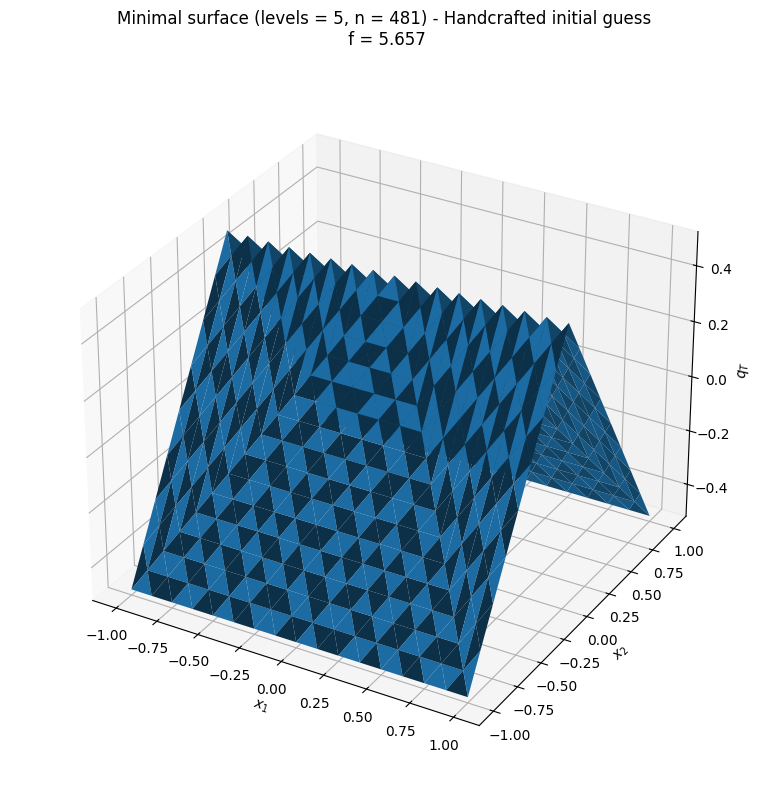

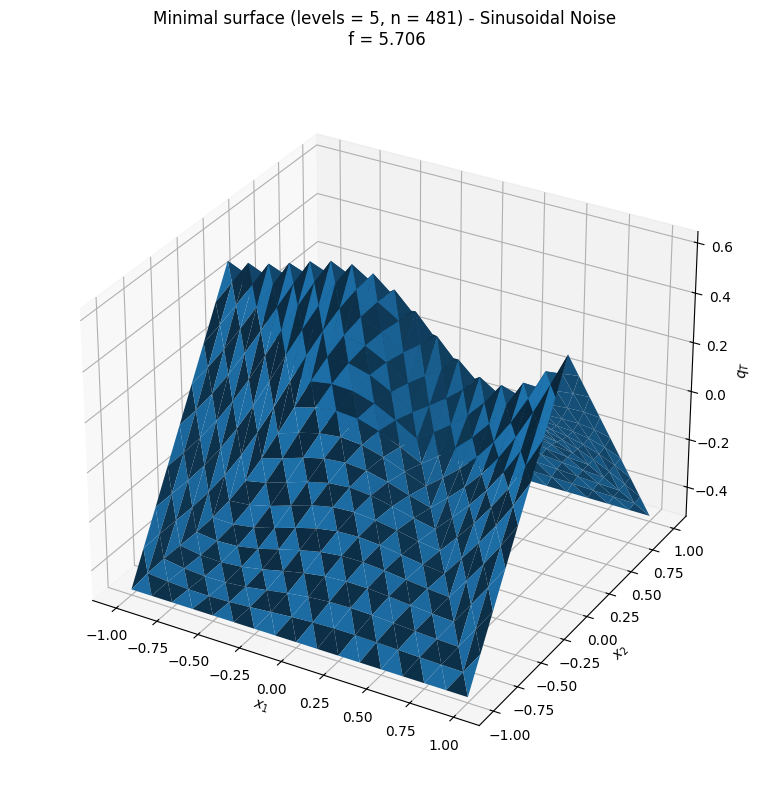

Iteration 2


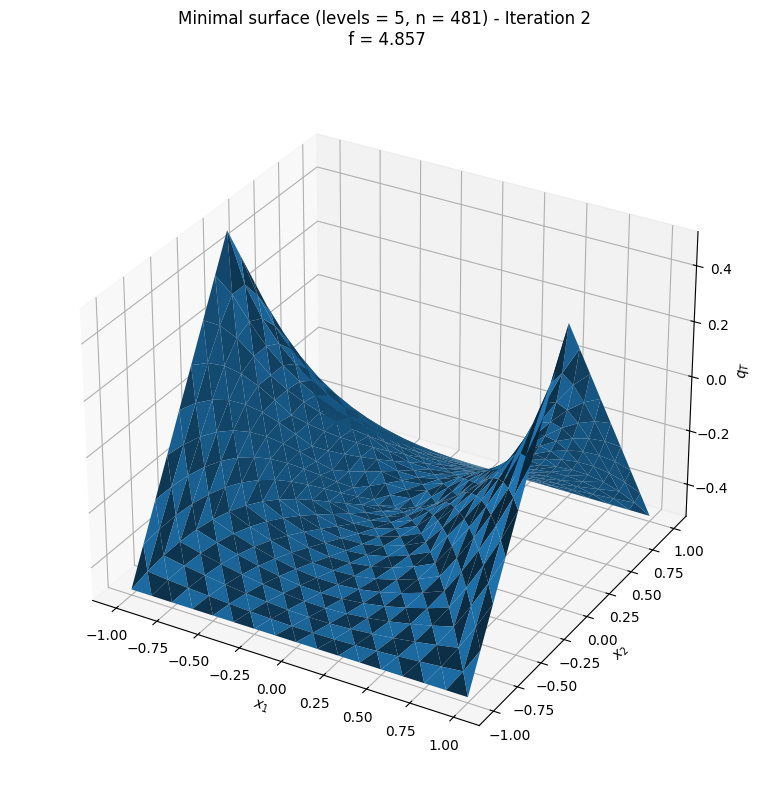

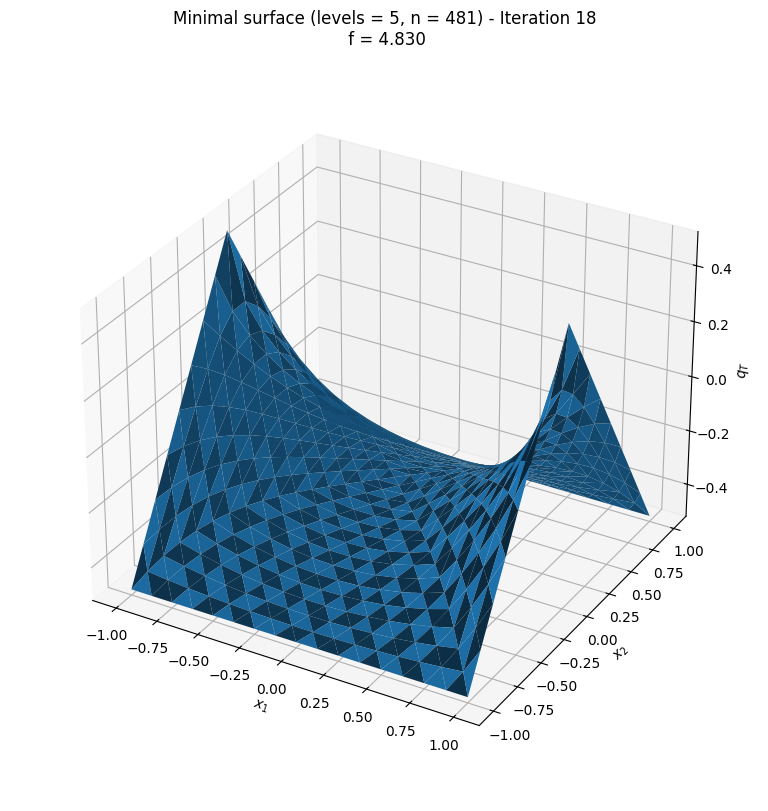

In [19]:
plot_solution(5, randomize = True, seed = SEED, it_to_plot = [2])

### Comparison of different full-memory quasi-Newton methods

This cell was entirely written by ChatGPT 5.6 Sol and creates the plots in Figures 5.2, 5.3, and 5.4, i.e. shows the median and interquartile range of the error and performance of the accepted runs.

In [26]:
def _summarize_ragged_runs(runs, extractor):
    """
    Convert a list of runs with possibly different iteration counts into
    median / Q1 / Q3 statistics.

    Parameters
    ----------
    runs : list[np.ndarray]
        Arrays whose first two axes are (method, iteration).

    extractor : callable
        Maps one run to an array of shape (n_methods, n_iterations).

    Returns
    -------
    median, q1, q3, count
        Arrays of shape (n_methods, max_iterations).
    """
    if len(runs) == 0:
        raise ValueError("No accepted runs to summarize.")

    n_runs = len(runs)
    n_methods = runs[0].shape[0]
    max_iterations = max(run.shape[1] for run in runs)

    values = np.full((n_runs, n_methods, max_iterations), np.nan, dtype=float)

    for run_index, run in enumerate(runs):
        extracted = extractor(run)
        n_iterations = extracted.shape[1]

        values[run_index, :, :n_iterations] = extracted

    q1, median, q3 = np.nanpercentile(values, [25, 50, 75], axis=0)

    count = np.sum(np.isfinite(values), axis=0)

    return median, q1, q3, count


def _configure_summary_axis(ax, log_y=True, grid_axis="both"):
    """
    Common formatting for the error/performance plots.
    """
    # Minor ticks on the iteration axis.
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    if log_y:
        ax.set_yscale("log")

    # Gray dotted grid at major and minor ticks.
    ax.grid(True, which="both", axis=grid_axis, linestyle=":", linewidth=0.8,
        color="gray", alpha=0.6)

    ax.set_axisbelow(True)


def plot_qn_error(names, error_list, log_y=True, min_run_fraction=0.5, desc = "BFGS", n_levels = 5, error_floor=None,
    grid_axis="both", figsize=(6, 6)):
    """
    Plot median error and IQR for all QN methods.

    Parameters
    ----------
    min_run_fraction : float
        Only show iterations represented by at least this fraction of the
        accepted runs.

        1.0 -> every displayed iteration occurs in every accepted run.
        0.5 -> at least half of accepted runs reached that iteration.

    error_floor : float or None
        Exact zero cannot be shown on a logarithmic axis. When log_y=True,
        values <= error_floor are displayed at this floor.

        Default: machine epsilon.
    """
    median, q1, q3, count = _summarize_ragged_runs(
        error_list,
        extractor=lambda run: run,
    )

    n_runs = len(error_list)
    min_runs = max(1, int(np.ceil(min_run_fraction * n_runs)))

    if error_floor is None:
        error_floor = np.finfo(float).eps

    fig, ax = plt.subplots(figsize=figsize)

    for method_index, name in enumerate(names):
        valid = count[method_index] >= min_runs

        iterations = np.arange(median.shape[1])[valid]

        med = median[method_index, valid]
        lower = q1[method_index, valid]
        upper = q3[method_index, valid]

        if log_y:
            # Needed in particular for the reference implementation,
            # whose error may be exactly zero.
            med = np.maximum(med, error_floor)
            lower = np.maximum(lower, error_floor)
            upper = np.maximum(upper, error_floor)

        line, = ax.plot(iterations, med, label=name, linewidth=2)

        ax.fill_between(iterations, lower, upper, alpha=0.2, color=line.get_color())

    _configure_summary_axis(ax, log_y=log_y, grid_axis=grid_axis)

    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\|B_k r_k - \widehat{B}_k r_k\|_\infty/\|B_k r_k\|_\infty$")
    ax.set_title(
        f"Inverse {desc} relative difference"
        f" (median and IQR over {n_runs} runs)\n"
        f"(levels = {n_levels} and n = {interior_dimension(n_levels)})",
        multialignment = "center"
    )

    ax.legend()
    fig.tight_layout()

    return fig, ax

def plot_qn_performance(names, performance_list, log_y=True, min_run_fraction=0.5, desc = "BFGS", n_levels = 5,
                         time_scale=1e3, time_unit="ms", figsize=(16, 5)):
    """
    Plot calculate, update, and total runtime using median + IQR.

    All three subplots use exactly the same y-axis limits.

    Parameters
    ----------
    names : list[str]
        Method names.

    performance_list : list[np.ndarray]
        One array per accepted run, with shape
        (n_methods, n_iterations, 2), where [:, :, 0] is calculate time
        and [:, :, 1] is update time.

    log_y : bool
        Whether to use a logarithmic y-axis.

    min_run_fraction : float
        Only plot iterations for which at least this fraction of accepted
        runs has data.

    time_scale : float
        Conversion factor from seconds. Default 1e3 gives milliseconds.

    time_unit : str
        Label for the converted time unit.
    """
    components = {
        "Calculate": lambda run: run[:, :, 0],
        "Update": lambda run: run[:, :, 1],
        "Calculate + update": lambda run: run[:, :, 0] + run[:, :, 1],
    }

    n_runs = len(performance_list)
    min_runs = max(1, int(np.ceil(min_run_fraction * n_runs)))

    summaries = {}

    for title, extractor in components.items():
        median, q1, q3, count = _summarize_ragged_runs(performance_list, extractor)
        summaries[title] = (median * time_scale, q1 * time_scale, q3 * time_scale, count)

    # Determine common y-axis limits from all three plots.
    lower_values = []
    upper_values = []

    for median, q1, q3, count in summaries.values():
        valid = count >= min_runs
        lower_values.extend(q1[valid])
        upper_values.extend(q3[valid])

    lower_values = np.asarray(lower_values)
    upper_values = np.asarray(upper_values)

    if log_y:
        positive = lower_values[lower_values > 0]

        if positive.size == 0:
            raise ValueError("Cannot use a logarithmic y-axis because no positive timing values were found.")

        y_min = np.min(positive)
        y_max = np.max(upper_values)

        # Small multiplicative padding for a logarithmic axis.
        y_limits = (y_min / 1.25, y_max * 1.25)

    else:
        y_min = np.min(lower_values)
        y_max = np.max(upper_values)
        padding = 0.05 * (y_max - y_min)

        if padding == 0:
            padding = 0.05 * max(abs(y_max), 1.0)

        y_limits = (max(0, y_min - padding), y_max + padding)

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    for ax, (title, (median, q1, q3, count)) in zip(axes, summaries.items()):
        for method_index, name in enumerate(names):
            valid = count[method_index] >= min_runs

            iterations = np.arange(median.shape[1])[valid]
            med = median[method_index, valid]
            lower = q1[method_index, valid]
            upper = q3[method_index, valid]

            line, = ax.plot(iterations, med, linewidth=2, label=name)
            ax.fill_between(iterations, lower, upper, color=line.get_color(), alpha=0.2)

        _configure_summary_axis(ax, log_y=log_y, grid_axis="both")

        ax.set_title(title)
        ax.set_xlabel("Iteration")
        ax.set_ylim(y_limits)

    axes[0].set_ylabel(f"Time per iteration [{time_unit}]")
    axes[-1].legend()

    fig.suptitle(f"Inverse {desc} performance (median and IQR over {n_runs} runs)\n"
        f"(levels = {n_levels} and n = {interior_dimension(n_levels)})",
                 multialignment = "center")
    fig.tight_layout()

    return fig, axes

This method compares different quasi-Newton methods by measuring the error and their performance.

To make the experiments somewhat meaningful, we conduct several (30) runs.

To make the results comparable, we have a reference implementation fully solve the problem and then have all other methods calculate and update based on this shared history.

In [24]:
def compare_qn(methods, reference, n_levels = 5, n_runs = 30, min_iterations = 30, max_tries = 100, seed = SEED):
  problem = setup_minimal_surface(n_levels)
  rng = np.random.default_rng(seed = seed)
  line_search = WolfePowellLineSearch()
  criterion = DecrementStoppingCriterion(sq_tol = 1e-10, k_max = 500)

  number_of_methods = len(methods)

  runs_left = n_runs
  tries_left = max_tries

  performance_list = []
  error_list = []

  tries = 0

  while runs_left > 0 and tries < max_tries:
    tries += 1
    problem.reset()
    reference.reset(problem.input_dimension, problem.preconditioner(reference.preconditioner_kind))

    initial_guess = problem.x0 + randomize_initial_guess(problem, rng, amplitude = 1.0)
    result = globalized_quasi_newton_method(problem, reference, criterion, line_search, initial_guess, history_level = 3)
    iterations = result["iterations"]

    if iterations >= min_iterations:
      print(f"Try {tries} with {iterations} iterations accepted")
      runs_left -= 1
      S = np.asarray(result["history"]["s_k"], dtype = float)
      Y = np.asarray(result["history"]["y_k"], dtype = float)
      R = np.asarray(result["history"]["r_k"], dtype = float)

      performance = np.zeros(shape = (number_of_methods, iterations, 2))
      errors      = np.zeros(shape = (number_of_methods, iterations))

      reference.reset(problem.input_dimension, problem.preconditioner(reference.preconditioner_kind))

      for method in methods.values():
        method.reset(problem.input_dimension, problem.preconditioner(method.preconditioner_kind))

      for i in range(iterations):
        #if i % 20 == 0:
          #print(f"[Try {tries}] Iteration: {i}")

        reference_result = reference.calculate(R[i])
        reference.update(S[i], Y[i])

        for j, (name, method) in enumerate(methods.items()):
          start_calculation = perf_counter()
          result = method.calculate(R[i])
          end_calculation = perf_counter()

          start_update = perf_counter()
          method.update(S[i], Y[i])
          end_update = perf_counter()

          performance[j, i, 0] = end_calculation - start_calculation
          performance[j, i, 1] = end_update - start_update

          errors[j, i] = np.max(np.abs(reference_result - result)) / np.max(np.abs(reference_result))

      performance_list.append(performance)
      error_list.append(errors)

  if runs_left > 0:
    print(f"Could not find {n_runs} runs with at least {min_iterations} iterations in {max_tries} tries...")

  return list(methods.keys()), performance_list, error_list

In [25]:
n_levels = 5
preconditioner = "poisson"
methods_desc = "BFGS"

methods = {
  "BFGS-SF": InverseBFGSSF(preconditioner),
  "BFGS-SF-OPT": InverseBFGSSFOPT(preconditioner),
  "BFGS-SPF": InverseBFGSSPF(preconditioner),
}

reference = InverseBFGSSPF(preconditioner)
if n_levels <= 6:
  methods["BFGS-Matrix"] = InverseBFGS(preconditioner)
  reference = InverseBFGS(preconditioner)


names, performance_list, error_list = compare_qn(
  methods =  methods, reference = reference,
  n_levels = n_levels, n_runs=50, min_iterations = 10, max_tries=200, seed=SEED)

Try 1 with 22 iterations accepted
Try 2 with 19 iterations accepted
Try 3 with 19 iterations accepted
Try 4 with 23 iterations accepted
Try 5 with 24 iterations accepted
Try 6 with 20 iterations accepted
Try 7 with 23 iterations accepted
Try 8 with 21 iterations accepted
Try 9 with 18 iterations accepted
Try 10 with 22 iterations accepted
Try 11 with 21 iterations accepted
Try 12 with 21 iterations accepted
Try 13 with 20 iterations accepted
Try 14 with 23 iterations accepted
Try 15 with 22 iterations accepted
Try 16 with 19 iterations accepted
Try 17 with 23 iterations accepted
Try 18 with 22 iterations accepted
Try 19 with 21 iterations accepted
Try 20 with 23 iterations accepted
Try 21 with 23 iterations accepted
Try 22 with 22 iterations accepted
Try 23 with 22 iterations accepted
Try 24 with 20 iterations accepted
Try 25 with 19 iterations accepted
Try 26 with 22 iterations accepted
Try 27 with 21 iterations accepted
Try 28 with 20 iterations accepted
Try 29 with 22 iterations acc

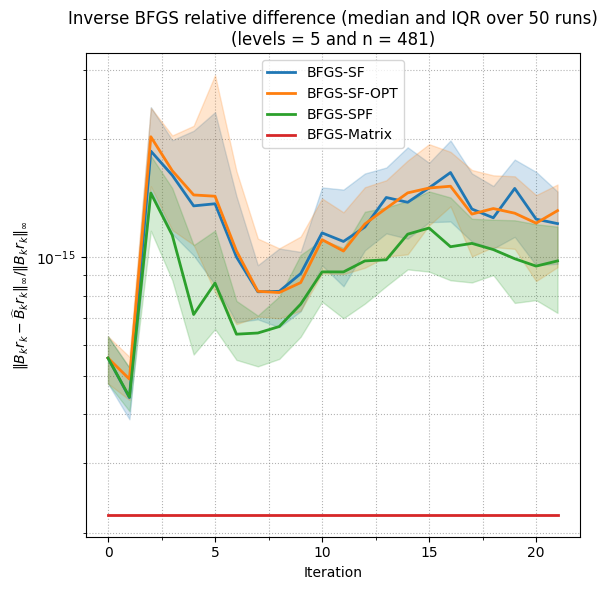

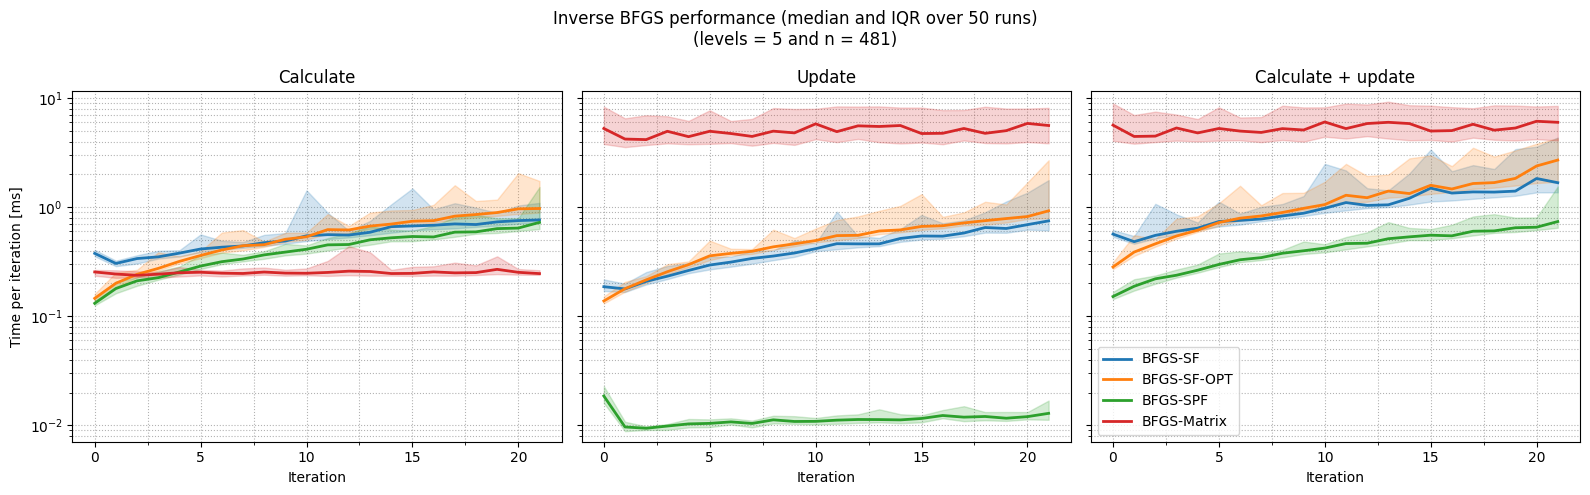

In [27]:
fig_error, ax_error = plot_qn_error(names, error_list, n_levels = n_levels, log_y = True)

fig_performance, ax_performance = plot_qn_performance(names, performance_list, n_levels = n_levels,
    log_y=True)
plt.show()

In [28]:
n_levels = 5
preconditioner = "poisson"
methods_desc = "DFP"

methods = {
  "DFP-SF": InverseDFPSF(preconditioner),
  "DFP-SF-OPT": InverseDFPSFOPT(preconditioner),
  "DFP-SPF": InverseDFPSPF(preconditioner)
}

reference = InverseDFPSPF(preconditioner)
if n_levels <= 6:
  methods["DFP-Matrix"] = InverseDFP(preconditioner)
  reference = InverseDFP(preconditioner)


names, performance_list, error_list = compare_qn(
  methods =  methods, reference = reference,
  n_levels = n_levels, n_runs=50, min_iterations = 10, max_tries=200, seed=SEED)

Try 1 with 27 iterations accepted
Try 2 with 24 iterations accepted
Try 3 with 24 iterations accepted
Try 4 with 30 iterations accepted
Try 5 with 33 iterations accepted
Try 6 with 24 iterations accepted
Try 7 with 26 iterations accepted
Try 8 with 28 iterations accepted
Try 9 with 23 iterations accepted
Try 10 with 31 iterations accepted
Try 11 with 32 iterations accepted
Try 12 with 27 iterations accepted
Try 13 with 25 iterations accepted
Try 14 with 42 iterations accepted
Try 15 with 34 iterations accepted
Try 16 with 24 iterations accepted
Try 17 with 36 iterations accepted
Try 18 with 30 iterations accepted
Try 19 with 27 iterations accepted
Try 20 with 31 iterations accepted
Try 21 with 32 iterations accepted
Try 22 with 32 iterations accepted
Try 23 with 29 iterations accepted
Try 24 with 28 iterations accepted
Try 25 with 26 iterations accepted
Try 26 with 31 iterations accepted
Try 27 with 27 iterations accepted
Try 28 with 27 iterations accepted
Try 29 with 30 iterations acc

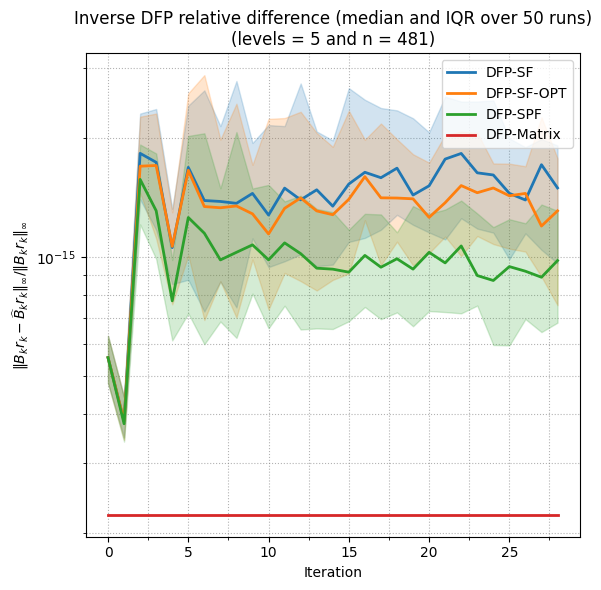

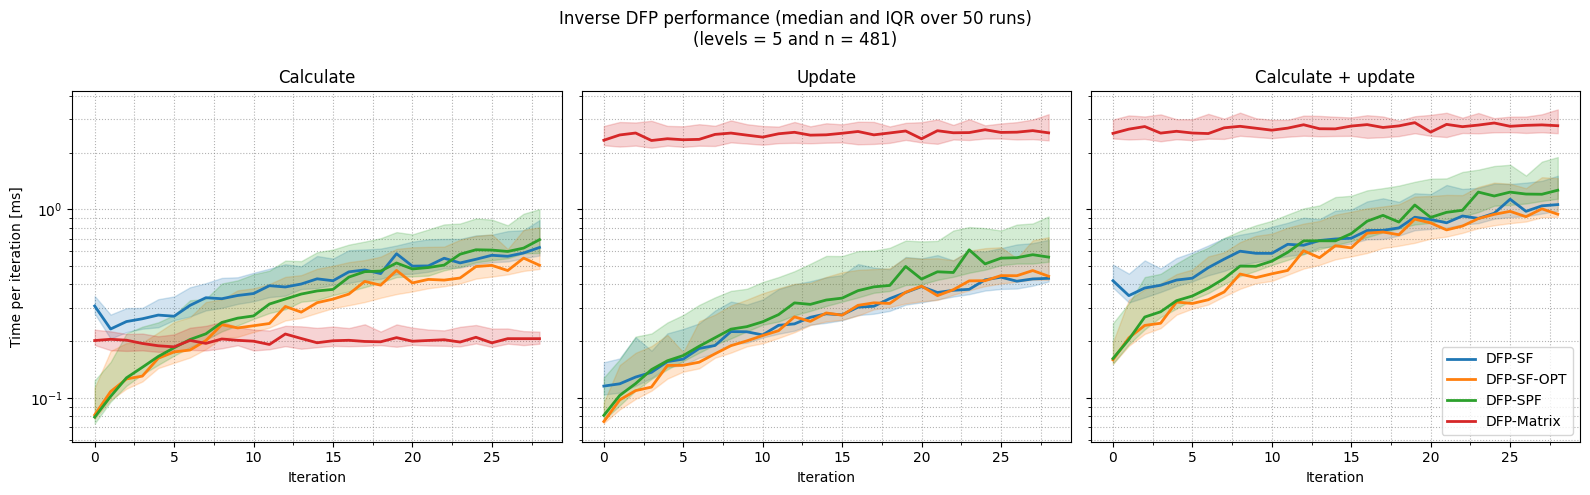

In [29]:
fig_error, ax_error = plot_qn_error(names, error_list, desc = methods_desc, n_levels = n_levels, log_y = True)

fig_performance, ax_performance = plot_qn_performance(names, performance_list, desc = methods_desc, n_levels = n_levels,
    log_y=True)
plt.show()

In [30]:
n_levels = 5
lam = 0.5
preconditioner = "poisson"
methods_desc = f"Broyden"

methods = {
  f"Broyden({lam})-SF": InverseBroydenSF(lam, preconditioner),
  f"Broyden({lam})-SF-OPT": InverseBroydenSFOPT(lam, preconditioner),
  f"Broyden({lam})-SPF": InverseBroydenSPF(lam, preconditioner)
}

reference = InverseBroydenSPF(lam, preconditioner)
if n_levels <= 6:
  methods[f"Broyden({lam})-Matrix"] = InverseBroyden(lam, preconditioner)
  reference = InverseBroyden(lam, preconditioner)


names, performance_list, error_list = compare_qn(
  methods =  methods, reference = reference,
  n_levels = n_levels, n_runs=50, min_iterations = 10, max_tries=200, seed=SEED)

Try 1 with 23 iterations accepted
Try 2 with 21 iterations accepted
Try 3 with 21 iterations accepted
Try 4 with 26 iterations accepted
Try 5 with 25 iterations accepted
Try 6 with 21 iterations accepted
Try 7 with 24 iterations accepted
Try 8 with 22 iterations accepted
Try 9 with 20 iterations accepted
Try 10 with 25 iterations accepted
Try 11 with 25 iterations accepted
Try 12 with 23 iterations accepted
Try 13 with 21 iterations accepted
Try 14 with 27 iterations accepted
Try 15 with 24 iterations accepted
Try 16 with 21 iterations accepted
Try 17 with 27 iterations accepted
Try 18 with 24 iterations accepted
Try 19 with 23 iterations accepted
Try 20 with 26 iterations accepted
Try 21 with 25 iterations accepted
Try 22 with 24 iterations accepted
Try 23 with 24 iterations accepted
Try 24 with 22 iterations accepted
Try 25 with 20 iterations accepted
Try 26 with 24 iterations accepted
Try 27 with 21 iterations accepted
Try 28 with 22 iterations accepted
Try 29 with 24 iterations acc

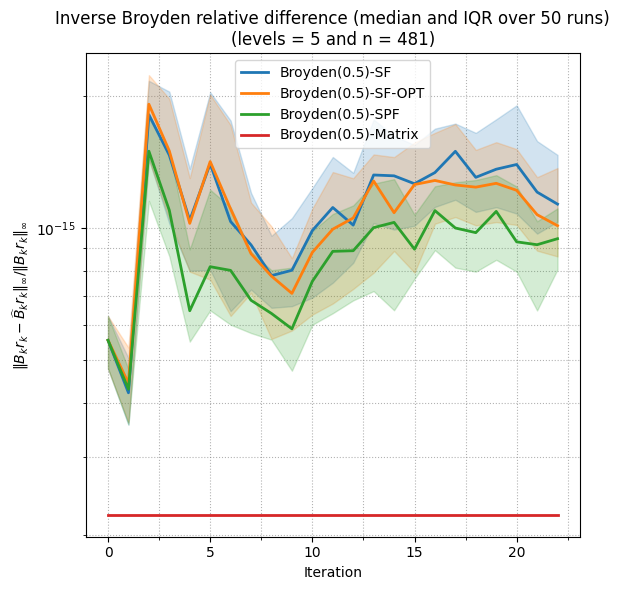

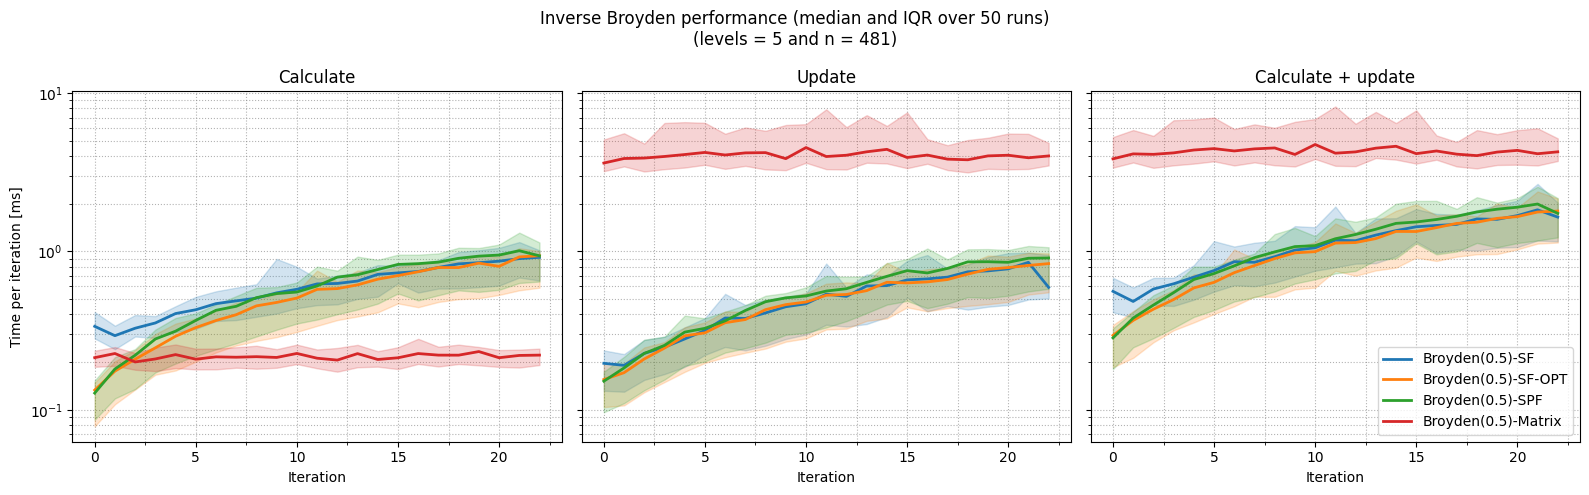

In [31]:
fig_error, ax_error = plot_qn_error(names, error_list, desc = methods_desc, log_y = True)

fig_performance, ax_performance = plot_qn_performance(names, performance_list, desc = methods_desc,
    log_y=True)
plt.show()

### Comparison of full-memory and limited-memory methods on shared history

In [32]:
n_levels = 8
preconditioner = "poisson"
methods_desc = "BFGS"

methods = {
  "BFGS-SPF": InverseBFGSSPF(preconditioner),
  "LM-BFGS-SPF (m = 5)": LMInverseBFGS(5, preconditioner),
  "LM-BFGS-SPF (m = 10)": LMInverseBFGS(10, preconditioner),
}

reference = InverseBFGSSPF(preconditioner)

names, performance_list, error_list = compare_qn(
  methods =  methods, reference = reference,
  n_levels = n_levels, n_runs=30, min_iterations = 50, max_tries=200, seed=SEED)

Try 1 with 68 iterations accepted
Try 2 with 69 iterations accepted
Try 3 with 68 iterations accepted
Try 4 with 71 iterations accepted
Try 5 with 70 iterations accepted
Try 6 with 69 iterations accepted
Try 7 with 70 iterations accepted
Try 8 with 69 iterations accepted
Try 9 with 68 iterations accepted
Try 10 with 70 iterations accepted
Try 11 with 71 iterations accepted
Try 12 with 69 iterations accepted
Try 13 with 69 iterations accepted
Try 14 with 71 iterations accepted
Try 15 with 70 iterations accepted
Try 16 with 69 iterations accepted
Try 17 with 72 iterations accepted
Try 18 with 70 iterations accepted
Try 19 with 70 iterations accepted
Try 20 with 70 iterations accepted
Try 21 with 71 iterations accepted
Try 22 with 70 iterations accepted
Try 23 with 70 iterations accepted
Try 24 with 69 iterations accepted
Try 25 with 69 iterations accepted
Try 26 with 71 iterations accepted
Try 27 with 69 iterations accepted
Try 28 with 70 iterations accepted
Try 29 with 71 iterations acc

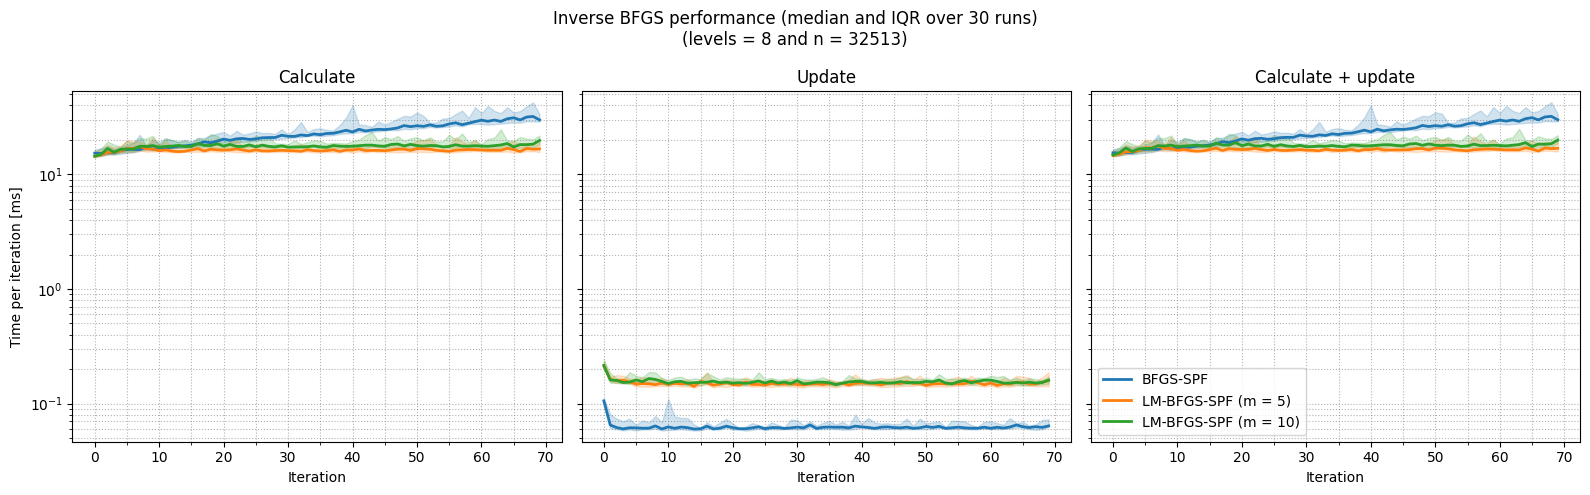

In [33]:
fig_performance, ax_performance = plot_qn_performance(names, performance_list, desc = methods_desc, n_levels = n_levels,
    log_y=True)
plt.show()

In [34]:
n_levels = 8
preconditioner = "poisson"
methods_desc = "DFP"

methods = {
  "DFP-SF": InverseDFPSF(preconditioner),
  "LM-DFP-SF (m = 5)": LMInverseDFP(5, preconditioner),
  "LM-DFP-SF (m = 10)": LMInverseDFP(10, preconditioner),
}

reference = InverseDFPSF(preconditioner)

names, performance_list, error_list = compare_qn(
  methods =  methods, reference = reference,
  n_levels = n_levels, n_runs=15, min_iterations = 50, max_tries=200, seed=SEED)

Try 1 with 239 iterations accepted
Try 2 with 239 iterations accepted
Try 3 with 238 iterations accepted
Try 4 with 241 iterations accepted
Try 5 with 245 iterations accepted
Try 6 with 239 iterations accepted
Try 7 with 240 iterations accepted
Try 8 with 241 iterations accepted
Try 9 with 238 iterations accepted
Try 10 with 243 iterations accepted
Try 11 with 247 iterations accepted
Try 12 with 238 iterations accepted
Try 13 with 239 iterations accepted
Try 14 with 234 iterations accepted
Try 15 with 245 iterations accepted


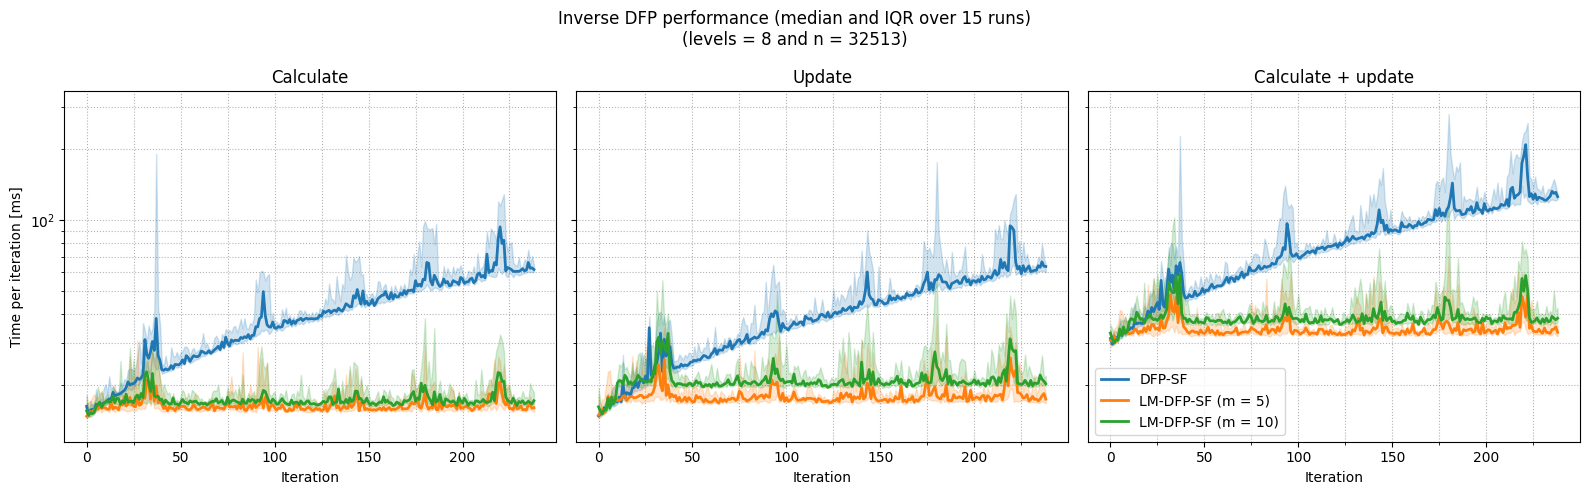

In [35]:
fig_performance, ax_performance = plot_qn_performance(names, performance_list, desc = methods_desc, n_levels = n_levels,
    log_y=True)
plt.show()

In [37]:
n_levels = 8
lam = 0.5
preconditioner = "poisson"
methods_desc = f"Broyden({lam})"

methods = {
  f"Broyden({lam})-SF": InverseBroydenSF(lam, preconditioner),
  f"LM-Broyden({lam})-SF (m = 5)": LMInverseBroyden(lam, 5, preconditioner),
  f"LM-Broyden({lam})-SF (m = 10)": LMInverseBroyden(lam, 10, preconditioner),
}

reference = InverseBroydenSF(lam, preconditioner)

names, performance_list, error_list = compare_qn(
  methods =  methods, reference = reference,
  n_levels = n_levels, n_runs=15, min_iterations = 50, max_tries=200, seed=SEED)

Try 1 with 80 iterations accepted
Try 2 with 80 iterations accepted
Try 3 with 80 iterations accepted
Try 4 with 82 iterations accepted
Try 5 with 83 iterations accepted
Try 6 with 80 iterations accepted
Try 7 with 81 iterations accepted
Try 8 with 82 iterations accepted
Try 9 with 80 iterations accepted
Try 10 with 82 iterations accepted
Try 11 with 83 iterations accepted
Try 12 with 80 iterations accepted
Try 13 with 81 iterations accepted
Try 14 with 84 iterations accepted
Try 15 with 81 iterations accepted


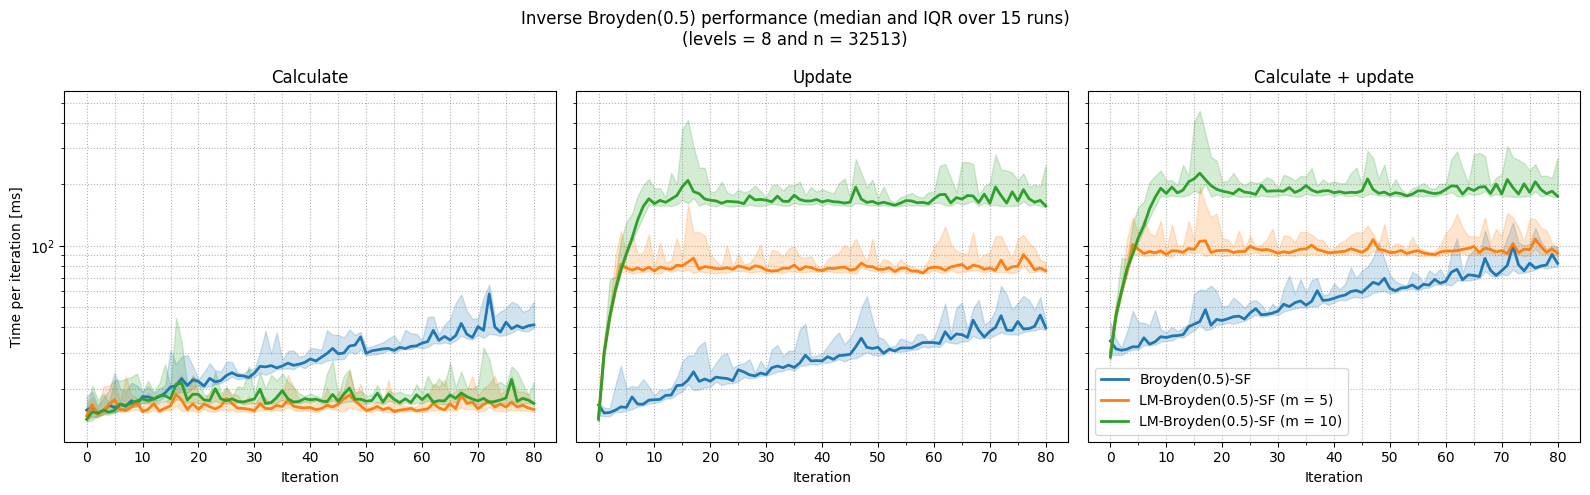

In [38]:
fig_performance, ax_performance = plot_qn_performance(names, performance_list, desc = methods_desc, n_levels = n_levels,
    log_y=True)
plt.show()

### Different update mechanisms for $p^{(k)}_j$

Here we compare the different methods to calculate the new auxiliary quantities $p_j^{(k)}$.

In [39]:
def update(S, Y, m):
    # Calculate p_j = H_j y_j for the current window, using the naive algorithm
    P = np.zeros_like(S)

    for j in range(m):
      # Apply updates 0, ..., j - 1.
      P[j] = Y[j].copy()
      for i in range(j):
        P[j] = P[j] - (Y[j].T @ P[i]) / (Y[i].T @ P[i]) * P[i]  +  (Y[j].T @ S[i]) /  (Y[i].T @ S[i]) * S[i]

    return P

In [40]:
def update2(S, Y, old_P, m):
    # Initial difference caused by deleting update 0
    delta_0 = Y[0].T @ old_P[0]
    rho_0 = 1.0 / (Y[0].T @ S[0])

    u = old_P[0].copy()
    v = S[0].copy()

    a = 1.0 / delta_0
    b = 0.0
    c = -rho_0

    P = np.zeros_like(old_P)

    # Correct the m - 1 values that are in both windows
    # Old pair i becomes new pair i - 1.
    for i in range(1, m):
        alpha = u.T @ Y[i]
        beta  = v.T @ Y[i]

        lam = a * alpha + b * beta
        mu  = b * alpha + c * beta

        P[i - 1] = old_P[i] + lam * u + mu * v

        delta_old = Y[i].T @ old_P[i]
        delta_new = Y[i].T @ P[i - 1]

        # Propagate the rank-two difference to the next update
        u = u - (alpha / delta_old) * old_P[i]
        v = v - (beta / delta_old) * old_P[i]

        a = a - lam**2 / delta_new
        b = b - lam * mu / delta_new
        c = c - mu**2 / delta_new

    # Calculate p for the new pair
    P[m - 1] = Y[m].copy()

    for i in range(m - 1):
        P[m - 1] = (P[m - 1] - (Y[m].T @ P[i]) / (Y[i + 1].T @ P[i]) * P[i] +
                  (Y[m].T @ S[i + 1].T) / (Y[i + 1].T @ S[i + 1].T) * S[i + 1].T)

    return P

In [43]:
m_candidates = [1, 2, 5, 10, 20, 50, 100, 200, 300,400, 500]
n_candidates = [2**n for n in range(5, 13)]
cond = 100

rng = np.random.default_rng(SEED)

max_iterations = max(m_candidates) + 2
performance1 = np.zeros(shape = (len(n_candidates), len(m_candidates)))
performance2 = np.zeros(shape = (len(n_candidates), len(m_candidates)))
errors = np.zeros(shape = (len(n_candidates), len(m_candidates)))
relative_frobenius = np.zeros(shape = (len(n_candidates), len(m_candidates)))

for i, n in enumerate(n_candidates):
  A = random_spd_with_condition(n, cond, rng)
  S = rng.uniform(-1, 1, (max_iterations, n))
  Y = S @ A

  print(f"cond(A) = {np.linalg.cond(A)}")
  print(f"Iteration {i + 1}: dimension = {n}")

  for j, m in enumerate(m_candidates):
    window_data_S = S[-(m + 1):]
    window_data_Y = Y[-(m + 1):]

    P_old = update(window_data_S[:-1], window_data_Y[:-1], m)

    start_1 = perf_counter()
    P1 = update(window_data_S[1:], window_data_Y[1:], m)
    end_1 = perf_counter()

    start_2 = perf_counter()
    P2 = update2(window_data_S, window_data_Y, P_old, m)
    end_2 = perf_counter()

    difference = P1 - P2

    performance1[i, j] = end_1 - start_1
    performance2[i, j] = end_2 - start_2
    errors[i, j] = np.median(np.linalg.norm(difference, axis = 1))
    relative_frobenius[i, j] = errors[i, j] / np.median(np.linalg.norm(P1, axis = 1))

cond(A) = 100.00000000000001
Iteration 1: dimension = 32
cond(A) = 100.00000000000004
Iteration 2: dimension = 64
cond(A) = 99.99999999999997
Iteration 3: dimension = 128
cond(A) = 100.00000000000007
Iteration 4: dimension = 256
cond(A) = 99.99999999999979
Iteration 5: dimension = 512
cond(A) = 100.00000000000026
Iteration 6: dimension = 1024
cond(A) = 99.99999999999963
Iteration 7: dimension = 2048
cond(A) = 99.99999999999943
Iteration 8: dimension = 4096


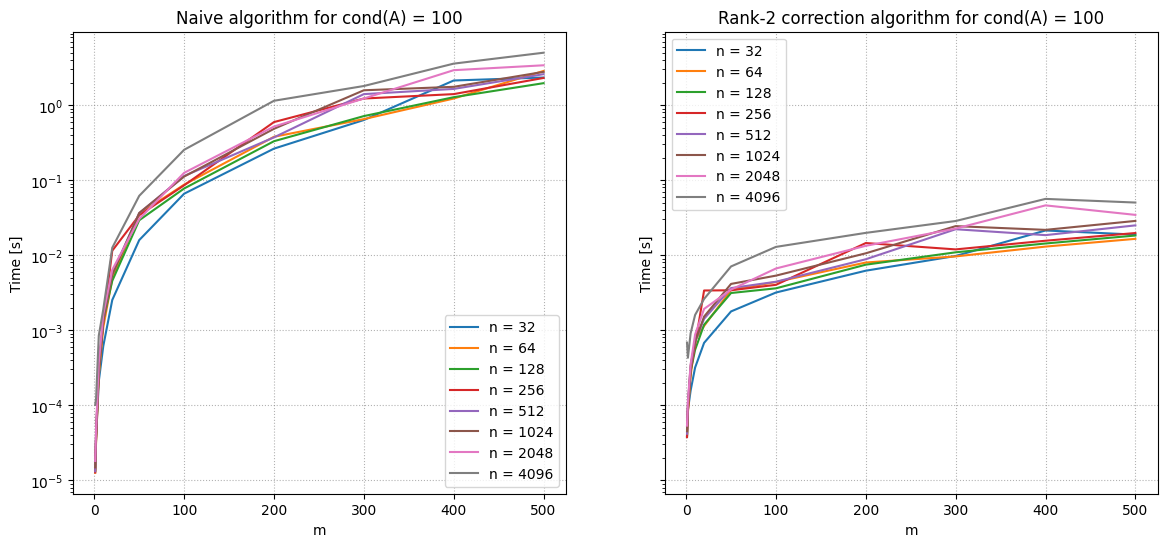

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# First heatmap
for i, n in enumerate(n_candidates):
  axes[0].plot(m_candidates, performance1[i], label = f"n = {n}")
  axes[1].plot(m_candidates, performance2[i], label = f"n = {n}")

axes[0].set_yscale("log")
axes[1].set_yscale("log")

axes[0].set_title(f"Naive algorithm for cond(A) = {cond}")
axes[1].set_title(f"Rank-2 correction algorithm for cond(A) = {cond}")

axes[0].set_xlabel("m")
axes[1].set_xlabel("m")

axes[0].set_ylabel("Time [s]")
axes[1].set_ylabel("Time [s]")

axes[0].grid(True, which="major", axis="both", linestyle=":", linewidth=0.8,
        color="gray", alpha=0.6)
axes[1].grid(True, which="major", axis="both", linestyle=":", linewidth=0.8,
        color="gray", alpha=0.6)


axes[0].legend()
axes[1].legend()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_747/805280930.py:10: SyntaxWarning: invalid escape sequence '\c'
  axes.set_ylabel("Relative Median Error w.r.t. $||\cdot||_F$")


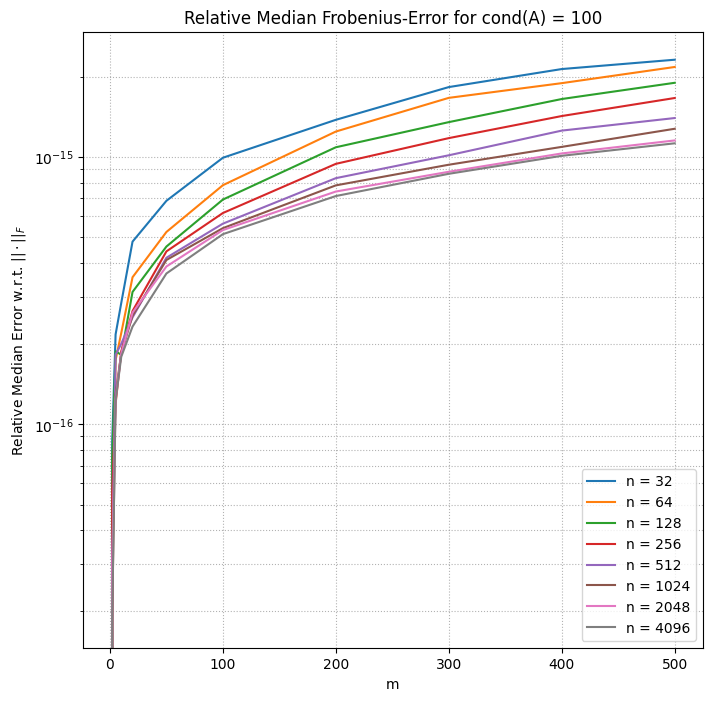

In [45]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True, sharey=True)

# First heatmap
for i, n in enumerate(n_candidates):
  axes.plot(m_candidates, relative_frobenius[i], label = f"n = {n}")

axes.set_yscale("log")
axes.set_title(f"Relative Median Frobenius-Error for cond(A) = {cond}")
axes.set_xlabel("m")
axes.set_ylabel("Relative Median Error w.r.t. $||\cdot||_F$")

axes.grid(True, which="both", axis="both", linestyle=":", linewidth=0.8,
        color="gray", alpha=0.6)

axes.legend()